
Analyzing v1.csv...
VERDICT: Inconsistent: dangerous voltage (max 82.5V > 80V), high frequency (1867.6Hz > 400Hz)
METRICS:
  n_discharges: 28
  max_voltage: 82.49
  mean_voltage: 39.19
  frequency: 1867.60
  duty_cycle: 66.41
  voltage_stability: 0.07


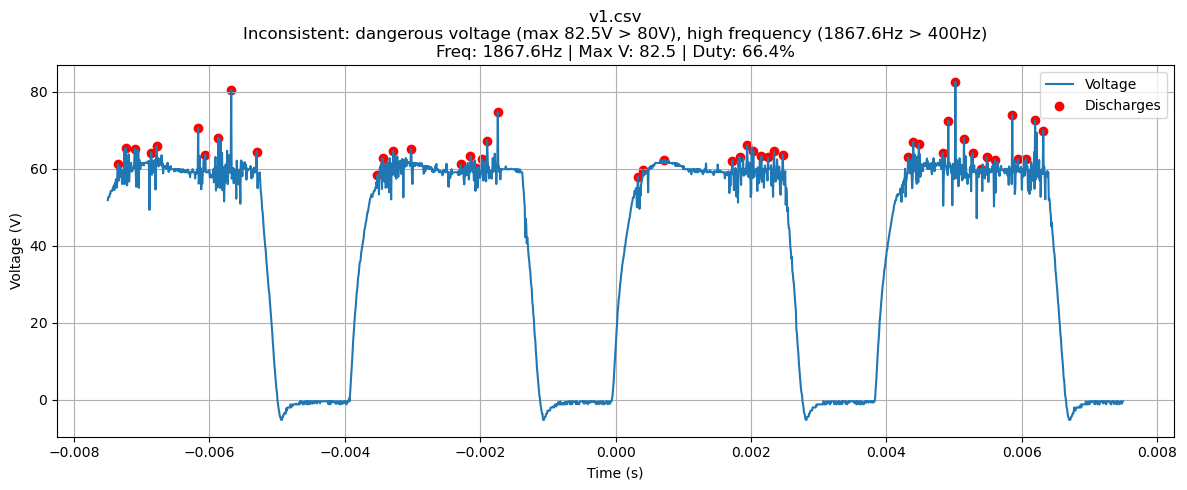


Analyzing v2.csv...
VERDICT: Inconsistent: high frequency (1867.6Hz > 400Hz)
METRICS:
  n_discharges: 28
  max_voltage: 61.55
  mean_voltage: 32.02
  frequency: 1867.60
  duty_cycle: 59.04
  voltage_stability: 0.05


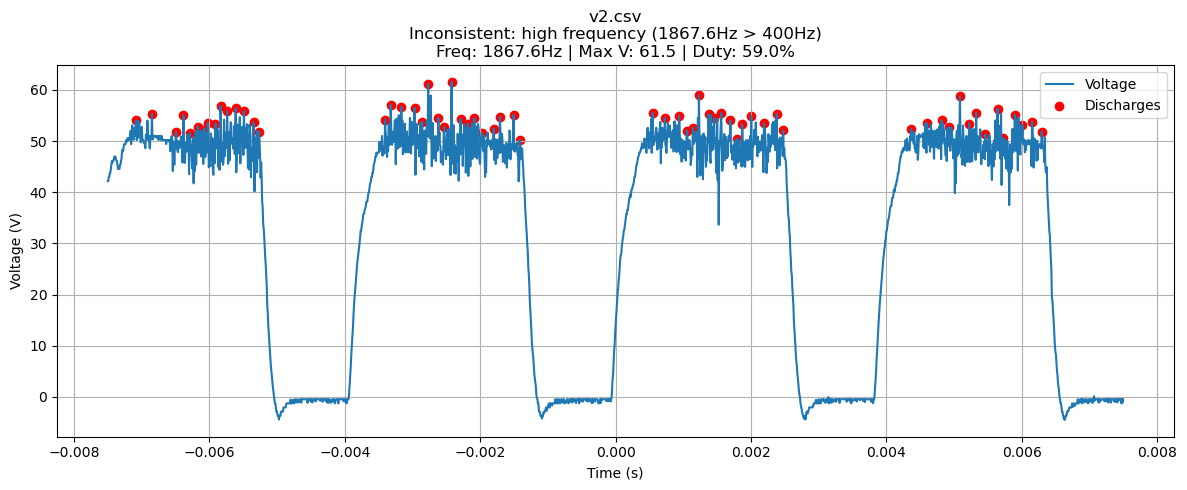

In [1]:
import numpy as np
import pandas as pd
from scipy import signal
import os
import re
import matplotlib.pyplot as plt

class ECDM_Consistency_Analyzer:
    def __init__(self):
        self.min_discharge_voltage = 20  # Minimum voltage to count as a discharge (V)
        self.max_safe_voltage = 80       # Maximum safe discharge voltage (V)
        self.min_frequency = 100         # Minimum discharge frequency (Hz)
        self.max_frequency = 400         # Maximum discharge frequency (Hz)
        self.min_duty_cycle = 30         # Minimum duty cycle (%)
        self.max_duty_cycle = 70         # Maximum duty cycle (%)

    def load_data(self, filepath):
        """Load and validate CSV data with robust error handling"""
        try:
            # Clean file path by stripping whitespace and normalizing
            clean_path = os.path.normpath(filepath.strip())
            
            if not os.path.exists(clean_path):
                raise FileNotFoundError(f"File not found: {clean_path}")
            
            df = pd.read_csv(clean_path, skiprows=1, header=None)
            if df.shape[1] < 2:
                raise ValueError("File must have at least 2 columns")
            
            # Convert to numeric and clean data
            time = df.iloc[:, 0].apply(self._convert_to_float).dropna().values
            voltage = df.iloc[:, 1].apply(self._convert_to_float).dropna().values * 1.0  # Ensure float
            
            if len(time) < 10 or len(voltage) < 10:
                raise ValueError("Insufficient data points (need at least 10 samples)")
                
            return time, voltage
        except Exception as e:
            print(f"\nERROR in {os.path.basename(filepath)}: {str(e)}")
            return None, None

    def _convert_to_float(self, s):
        """Robust scientific notation conversion"""
        try:
            return float(re.sub(r'[^\d\.\-+eE]', '', str(s)))
        except:
            return np.nan

    def _analyze_discharges(self, voltage, time):
        """Safe discharge analysis with fallback values"""
        try:
            peaks, properties = signal.find_peaks(
                voltage, 
                height=self.min_discharge_voltage,
                distance=10,
                prominence=5,
                width=3
            )
            
            if len(peaks) == 0:
                return {
                    'n_discharges': 0,
                    'max_voltage': np.max(voltage) if len(voltage) > 0 else 0,
                    'mean_voltage': np.mean(voltage) if len(voltage) > 0 else 0,
                    'frequency': 0,
                    'duty_cycle': 0,
                    'voltage_stability': 0
                }
            
            duration = time[-1] - time[0] if len(time) > 1 else 1
            discharge_widths = properties['widths'] * np.mean(np.diff(time)) if len(time) > 1 else 0
            duty_cycle = np.mean(discharge_widths) * len(peaks) / duration * 100 if duration > 0 else 0
            
            return {
                'n_discharges': len(peaks),
                'max_voltage': np.max(voltage[peaks]),
                'mean_voltage': np.mean(voltage),
                'frequency': len(peaks)/duration if duration > 0 else 0,
                'duty_cycle': duty_cycle,
                'voltage_stability': np.std(voltage[peaks])/np.mean(voltage[peaks]) if len(peaks) > 1 else 0
            }
        except Exception as e:
            print(f"Discharge analysis error: {str(e)}")
            return {
                'n_discharges': 0,
                'max_voltage': 0,
                'mean_voltage': 0,
                'frequency': 0,
                'duty_cycle': 0,
                'voltage_stability': 0
            }

    def check_consistency(self, filepath):
        """Bulletproof consistency check"""
        try:
            time, voltage = self.load_data(filepath)
            if time is None:
                return {
                    'consistent': False,
                    'reason': 'Invalid data (could not load file)',
                    'file': os.path.basename(filepath),
                    'metrics': None
                }
            
            metrics = self._analyze_discharges(voltage, time)
            if metrics is None:
                return {
                    'consistent': False,
                    'reason': 'Analysis failed',
                    'file': os.path.basename(filepath),
                    'metrics': None
                }
            
            reasons = []
            if metrics['n_discharges'] == 0:
                reasons.append("no discharges detected")
            elif metrics['max_voltage'] < self.min_discharge_voltage:
                reasons.append(f"weak discharges (max {metrics['max_voltage']:.1f}V < {self.min_discharge_voltage}V)")
            elif metrics['max_voltage'] > self.max_safe_voltage:
                reasons.append(f"dangerous voltage (max {metrics['max_voltage']:.1f}V > {self.max_safe_voltage}V)")
            
            if metrics['frequency'] > 0:  # Only check if discharges exist
                if metrics['frequency'] < self.min_frequency:
                    reasons.append(f"low frequency ({metrics['frequency']:.1f}Hz < {self.min_frequency}Hz)")
                elif metrics['frequency'] > self.max_frequency:
                    reasons.append(f"high frequency ({metrics['frequency']:.1f}Hz > {self.max_frequency}Hz)")
                
                if metrics['duty_cycle'] < self.min_duty_cycle:
                    reasons.append(f"low duty cycle ({metrics['duty_cycle']:.1f}% < {self.min_duty_cycle}%)")
                elif metrics['duty_cycle'] > self.max_duty_cycle:
                    reasons.append(f"high duty cycle ({metrics['duty_cycle']:.1f}% > {self.max_duty_cycle}%)")
                
                if metrics['voltage_stability'] > 0.3:
                    reasons.append("unstable discharges")
            
            return {
                'consistent': len(reasons) == 0,
                'reason': "Consistent" if len(reasons) == 0 else f"Inconsistent: {', '.join(reasons)}",
                'metrics': metrics,
                'file': os.path.basename(filepath)
            }
        except Exception as e:
            print(f"Consistency check error: {str(e)}")
            return {
                'consistent': False,
                'reason': f"Analysis crashed: {str(e)}",
                'file': os.path.basename(filepath),
                'metrics': None
            }

    def plot_results(self, filepath):
        """Visualization with error handling"""
        result = self.check_consistency(filepath)
        time, voltage = self.load_data(filepath)
        
        if time is None or voltage is None:
            print(f"Cannot plot {result['file']} - no valid data")
            return
        
        plt.figure(figsize=(12, 5))
        plt.plot(time, voltage, label='Voltage')
        
        try:
            peaks, _ = signal.find_peaks(
                voltage,
                height=self.min_discharge_voltage,
                distance=10,
                prominence=5
            )
            if len(peaks) > 0:
                plt.scatter(time[peaks], voltage[peaks], color='red', label='Discharges')
        except:
            pass
        
        title = f"{result['file']}\n{result['reason']}"
        if result['metrics']:
            title += f"\nFreq: {result['metrics']['frequency']:.1f}Hz | Max V: {result['metrics']['max_voltage']:.1f} | Duty: {result['metrics']['duty_cycle']:.1f}%"
        
        plt.title(title)
        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        if len(peaks) > 0:
            plt.legend()
        plt.tight_layout()
        plt.show()

# Fixed Usage Example
if __name__ == "__main__":
    analyzer = ECDM_Consistency_Analyzer()
    
    # Properly formatted file paths
    test_files = [
        r"C:\ECDM project\sample\v1.csv",  # Raw string for Windows paths
        r"C:\ECDM project\sample\v2.csv"
    ]
    
    for file in test_files:
        print(f"\n{'='*50}\nAnalyzing {os.path.basename(file)}...")
        result = analyzer.check_consistency(file)
        
        if result['metrics'] is not None:
            print(f"VERDICT: {result['reason']}")
            print("METRICS:")
            for k, v in result['metrics'].items():
                print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")
        else:
            print(f"ERROR: {result['reason']}")
        
        analyzer.plot_results(file)


Analyzing scope_2.csv...
VERDICT: Inconsistent: no discharges detected
METRICS:
  n_discharges: 0
  max_voltage: 2.40
  mean_voltage: -14.47
  frequency: 0
  duty_cycle: 0
  voltage_stability: 0
  time_duration: 0.01


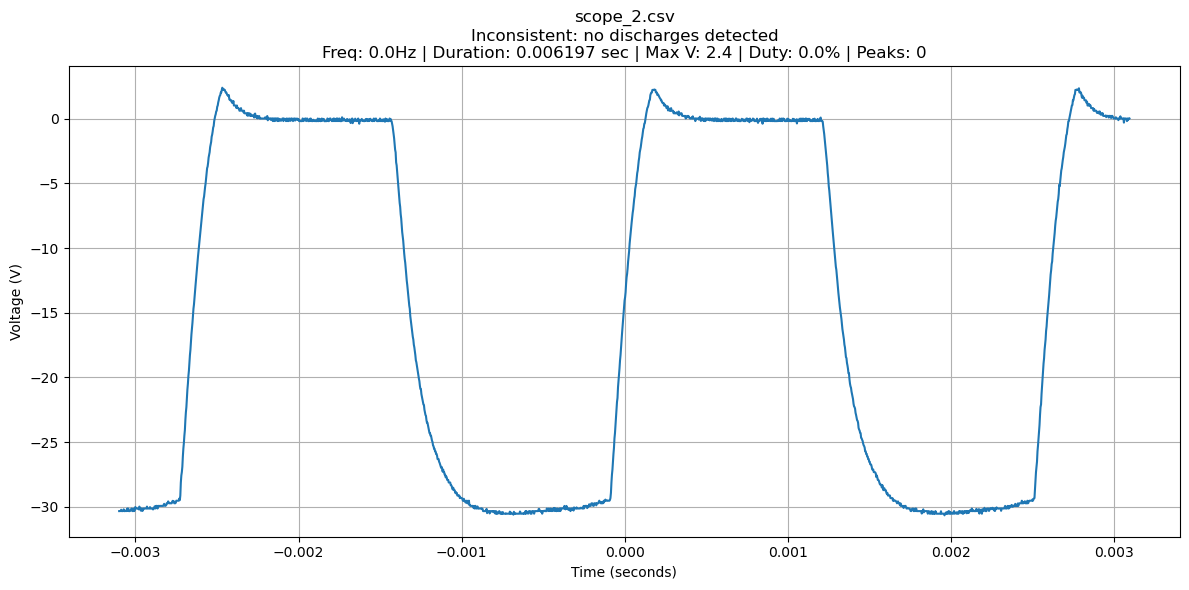


Analyzing scope_6.csv...
VERDICT: Inconsistent: no discharges detected
METRICS:
  n_discharges: 0
  max_voltage: 1.06
  mean_voltage: -13.36
  frequency: 0
  duty_cycle: 0
  voltage_stability: 0
  time_duration: 0.00


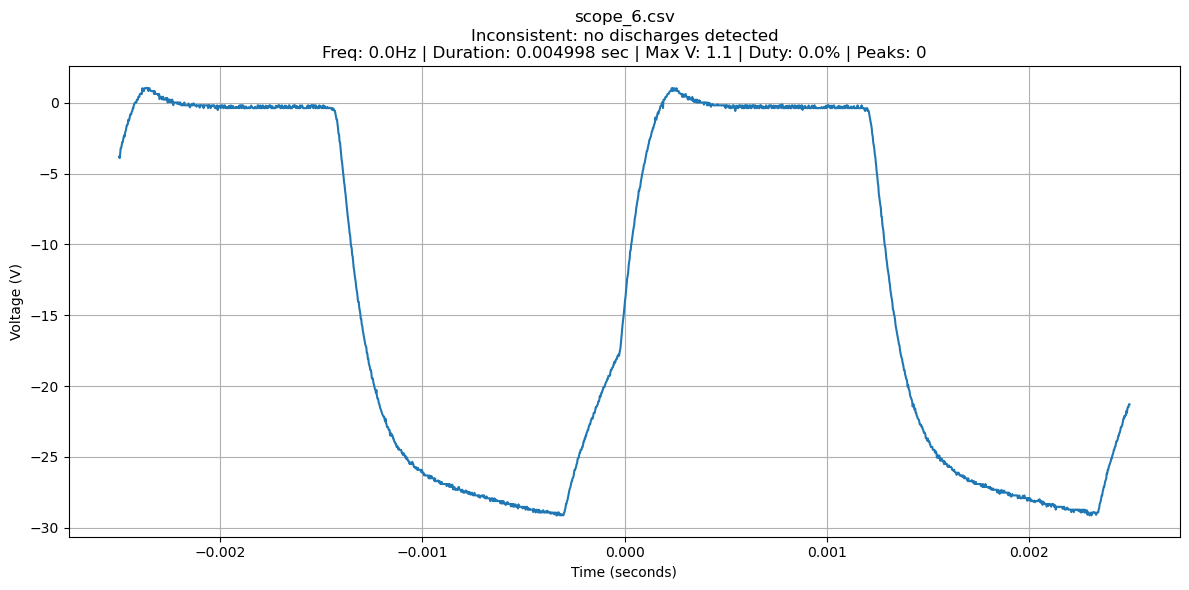

In [3]:
import numpy as np
import pandas as pd
from scipy import signal
import os
import re
import matplotlib.pyplot as plt

class ECDM_Consistency_Analyzer:
    def __init__(self):
        self.min_discharge_voltage = 20  # Minimum voltage to count as a discharge (V)
        self.max_safe_voltage = 80       # Maximum safe discharge voltage (V)
        self.min_frequency = 100         # Minimum discharge frequency (Hz)
        self.max_frequency = 1500        # Increased maximum frequency (Hz) [from 400]
        self.min_duty_cycle = 30         # Minimum duty cycle (%)
        self.max_duty_cycle = 70         # Maximum duty cycle (%)
        self.expected_time_units = 'seconds'  # Verify this matches your data

    def load_data(self, filepath):
        """Load and validate CSV data with time unit verification"""
        try:
            clean_path = os.path.normpath(filepath.strip())
            
            if not os.path.exists(clean_path):
                raise FileNotFoundError(f"File not found: {clean_path}")
            
            df = pd.read_csv(clean_path, skiprows=1, header=None)
            if df.shape[1] < 2:
                raise ValueError("File must have at least 2 columns")
            
            # Convert to numeric and clean data
            time = df.iloc[:, 0].apply(self._convert_to_float).dropna().values
            voltage = df.iloc[:, 1].apply(self._convert_to_float).dropna().values * 1.0
            
            # Time unit verification
            total_duration = time[-1] - time[0] if len(time) > 1 else 0
            if total_duration > 0 and total_duration < 0.001:  # Suspiciously short duration
                print(f"Warning: Very short time duration ({total_duration:.6f} sec) - verify time units")
            
            if len(time) < 10 or len(voltage) < 10:
                raise ValueError("Insufficient data points (need at least 10 samples)")
                
            return time, voltage
        except Exception as e:
            print(f"\nERROR in {os.path.basename(filepath)}: {str(e)}")
            return None, None

    def _convert_to_float(self, s):
        """Robust scientific notation conversion"""
        try:
            return float(re.sub(r'[^\d\.\-+eE]', '', str(s)))
        except:
            return np.nan

    def _analyze_discharges(self, voltage, time):
        """Enhanced discharge analysis with time unit checks"""
        try:
            if len(time) <= 1:
                return {
                    'n_discharges': 0,
                    'max_voltage': np.max(voltage) if len(voltage) > 0 else 0,
                    'mean_voltage': np.mean(voltage) if len(voltage) > 0 else 0,
                    'frequency': 0,
                    'duty_cycle': 0,
                    'voltage_stability': 0,
                    'time_duration': 0
                }
            
            duration = time[-1] - time[0]
            peaks, properties = signal.find_peaks(
                voltage, 
                height=self.min_discharge_voltage,
                distance=10,
                prominence=5,
                width=3
            )
            
            if len(peaks) == 0:
                return {
                    'n_discharges': 0,
                    'max_voltage': np.max(voltage),
                    'mean_voltage': np.mean(voltage),
                    'frequency': 0,
                    'duty_cycle': 0,
                    'voltage_stability': 0,
                    'time_duration': duration
                }
            
            # Calculate metrics
            discharge_widths = properties['widths'] * np.mean(np.diff(time))
            duty_cycle = np.mean(discharge_widths) * len(peaks) / duration * 100 if duration > 0 else 0
            frequency = len(peaks)/duration if duration > 0 else 0
            
            return {
                'n_discharges': len(peaks),
                'max_voltage': np.max(voltage[peaks]),
                'mean_voltage': np.mean(voltage),
                'frequency': frequency,
                'duty_cycle': duty_cycle,
                'voltage_stability': np.std(voltage[peaks])/np.mean(voltage[peaks]) if len(peaks) > 1 else 0,
                'time_duration': duration
            }
        except Exception as e:
            print(f"Discharge analysis error: {str(e)}")
            return {
                'n_discharges': 0,
                'max_voltage': 0,
                'mean_voltage': 0,
                'frequency': 0,
                'duty_cycle': 0,
                'voltage_stability': 0,
                'time_duration': 0
            }

    def check_consistency(self, filepath):
        """Enhanced consistency check with time duration reporting"""
        try:
            time, voltage = self.load_data(filepath)
            if time is None:
                return {
                    'consistent': False,
                    'reason': 'Invalid data (could not load file)',
                    'file': os.path.basename(filepath),
                    'metrics': None
                }
            
            metrics = self._analyze_discharges(voltage, time)
            if metrics is None:
                return {
                    'consistent': False,
                    'reason': 'Analysis failed',
                    'file': os.path.basename(filepath),
                    'metrics': None
                }
            
            reasons = []
            if metrics['n_discharges'] == 0:
                reasons.append("no discharges detected")
            elif metrics['max_voltage'] < self.min_discharge_voltage:
                reasons.append(f"weak discharges (max {metrics['max_voltage']:.1f}V < {self.min_discharge_voltage}V)")
            elif metrics['max_voltage'] > self.max_safe_voltage:
                reasons.append(f"dangerous voltage (max {metrics['max_voltage']:.1f}V > {self.max_safe_voltage}V)")
            
            if metrics['frequency'] > 0:
                if metrics['frequency'] < self.min_frequency:
                    reasons.append(f"low frequency ({metrics['frequency']:.1f}Hz < {self.min_frequency}Hz)")
                elif metrics['frequency'] > self.max_frequency:
                    reasons.append(f"high frequency ({metrics['frequency']:.1f}Hz > {self.max_frequency}Hz)")
                
                if metrics['duty_cycle'] < self.min_duty_cycle:
                    reasons.append(f"low duty cycle ({metrics['duty_cycle']:.1f}% < {self.min_duty_cycle}%)")
                elif metrics['duty_cycle'] > self.max_duty_cycle:
                    reasons.append(f"high duty cycle ({metrics['duty_cycle']:.1f}% > {self.max_duty_cycle}%)")
                
                if metrics['voltage_stability'] > 0.3:
                    reasons.append("unstable discharges")
            
            # Add time duration to metrics for debugging
            metrics['time_duration'] = metrics.get('time_duration', 0)
            
            return {
                'consistent': len(reasons) == 0,
                'reason': "Consistent" if len(reasons) == 0 else f"Inconsistent: {', '.join(reasons)}",
                'metrics': metrics,
                'file': os.path.basename(filepath)
            }
        except Exception as e:
            print(f"Consistency check error: {str(e)}")
            return {
                'consistent': False,
                'reason': f"Analysis crashed: {str(e)}",
                'file': os.path.basename(filepath),
                'metrics': None
            }

    def plot_results(self, filepath):
        """Enhanced visualization with time unit info"""
        result = self.check_consistency(filepath)
        time, voltage = self.load_data(filepath)
        
        if time is None or voltage is None:
            print(f"Cannot plot {result['file']} - no valid data")
            return
        
        plt.figure(figsize=(12, 6))
        plt.plot(time, voltage, label='Voltage')
        
        try:
            peaks, _ = signal.find_peaks(
                voltage,
                height=self.min_discharge_voltage,
                distance=10,
                prominence=5
            )
            if len(peaks) > 0:
                plt.scatter(time[peaks], voltage[peaks], color='red', label='Discharges')
        except:
            pass
        
        title = f"{result['file']}\n{result['reason']}"
        if result['metrics']:
            m = result['metrics']
            title += (f"\nFreq: {m['frequency']:.1f}Hz | Duration: {m['time_duration']:.6f} sec | "
                     f"Max V: {m['max_voltage']:.1f} | Duty: {m['duty_cycle']:.1f}% | "
                     f"Peaks: {m['n_discharges']}")
        
        plt.title(title)
        plt.xlabel(f"Time ({self.expected_time_units})")
        plt.ylabel("Voltage (V)")
        plt.grid(True)
        if len(peaks) > 0:
            plt.legend()
        plt.tight_layout()
        plt.show()

# Usage Example
if __name__ == "__main__":
    analyzer = ECDM_Consistency_Analyzer()
    
    test_files = [
        r"C:\ECDM project\sample\scope_2.csv",
        r"C:\ECDM project\sample\scope_6.csv"
    ]
    
    for file in test_files:
        print(f"\n{'='*50}\nAnalyzing {os.path.basename(file)}...")
        result = analyzer.check_consistency(file)
        
        if result['metrics'] is not None:
            print(f"VERDICT: {result['reason']}")
            print("METRICS:")
            for k, v in result['metrics'].items():
                print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")
        else:
            print(f"ERROR: {result['reason']}")
        
        analyzer.plot_results(file)

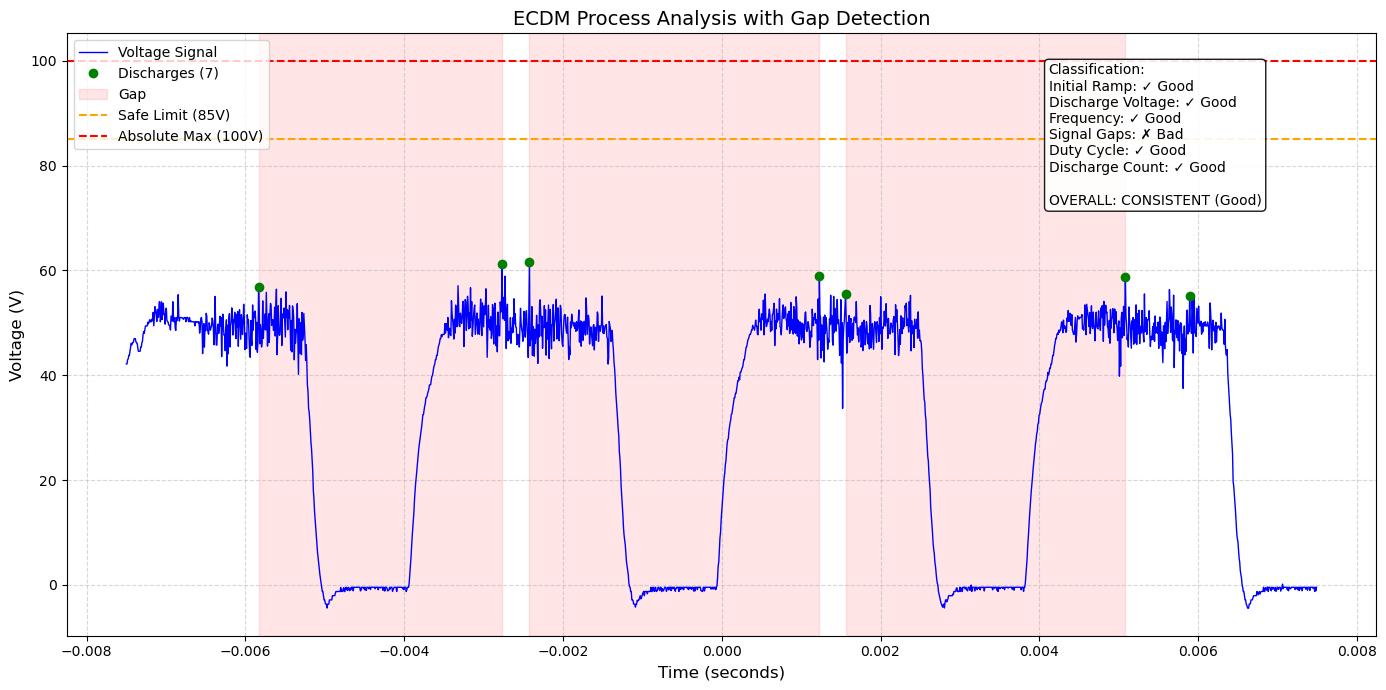


ANALYSIS RESULTS:
discharges     : 7
max_voltage    : 61.55
min_voltage    : -4.47
mean_voltage   : 32.02
frequency      : 511.51
duty_cycle     : 64.60

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Signal Gaps         : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: CONSISTENT (Good)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def detect_voltage_gaps(time, voltage, peaks, min_gap_duration=0.002):
    """Detect significant gaps between discharges."""
    if len(peaks) < 2:
        return False  # Not enough peaks to determine gaps
    
    # Calculate time intervals between discharges
    discharge_intervals = np.diff(time[peaks])
    
    # Find gaps longer than threshold
    large_gaps = discharge_intervals > min_gap_duration
    gap_percentage = np.mean(large_gaps) * 100
    
    # If more than 20% of intervals are gaps → inconsistent
    return gap_percentage > 20

def classify_ecdm(stats, time, voltage, peaks):
    """Enhanced classification with gap detection."""
    classifications = []
    
    # 1. Initial Curve Check
    initial_slope = np.polyfit(np.linspace(0,1,100), stats['voltage'][:100], 1)[0]
    classifications.append(('Initial Ramp', 'Good' if initial_slope > 2 else 'Bad'))
    
    # 2. Discharge Voltage
    classifications.append(('Discharge Voltage', 
                          'Good' if 40 <= stats['max_voltage'] <= 80 else 'Bad'))
    
    # 3. Frequency (adjusted range)
    classifications.append(('Frequency', 
                          'Good' if 100 <= stats['frequency'] <= 3000 else 'Bad'))
    
    # 4. Signal Continuity (now includes gap detection)
    has_gaps = detect_voltage_gaps(time, voltage, peaks)
    classifications.append(('Signal Gaps', 
                          'Bad' if has_gaps else 'Good'))
    
    # 5. Duty Cycle
    classifications.append(('Duty Cycle', 
                          'Good' if 30 <= stats['duty_cycle'] <= 70 else 'Bad'))
    
    # 6. Discharge Count
    classifications.append(('Discharge Count', 
                          'Good' if stats['discharges'] > 5 else 'Bad'))
    
    # Overall classification
    good_count = sum(1 for _, status in classifications if status == 'Good')
    overall = 'CONSISTENT (Good)' if good_count >= 5 else 'INCONSISTENT (Bad)'
    
    return classifications, overall

def analyze_ecdm_process(csv_file):
    """Final version with gap detection."""
    try:
        data = pd.read_csv(csv_file, header=None).apply(pd.to_numeric, errors='coerce').dropna()
        time = data.iloc[:, 0].values
        voltage = data.iloc[:, 1].values
        
        # Find discharges with stricter parameters
        peaks, _ = find_peaks(voltage, height=20, prominence=15, distance=10)
        
        stats = {
            'voltage': voltage,
            'discharges': len(peaks),
            'max_voltage': np.max(voltage),
            'min_voltage': np.min(voltage),
            'mean_voltage': np.mean(voltage),
            'frequency': 1/np.mean(np.diff(time[peaks])) if len(peaks) > 1 else 0,
            'duty_cycle': 100 * np.sum(voltage > (0.5*np.max(voltage))) / len(voltage)
        }
        
        # Enhanced classification
        classifications, overall = classify_ecdm(stats, time, voltage, peaks)
        
        # Visualization with gap highlighting
        plt.figure(figsize=(14, 7))
        
        # Plot voltage and mark gaps
        plt.plot(time, voltage, 'b-', linewidth=1, label='Voltage Signal')
        plt.plot(time[peaks], voltage[peaks], 'go', markersize=6, label=f'Discharges ({stats["discharges"]})')
        
        # Highlight gaps between discharges
        if len(peaks) > 1:
            for i in range(len(peaks)-1):
                if time[peaks[i+1]] - time[peaks[i]] > 0.002:  # Gap threshold
                    plt.axvspan(time[peaks[i]], time[peaks[i+1]], 
                               color='red', alpha=0.1, label='Gap' if i==0 else "")
        
        plt.axhline(85, color='orange', linestyle='--', label='Safe Limit (85V)')
        plt.axhline(100, color='red', linestyle='--', label='Absolute Max (100V)')
        
        # Add classification box
        class_text = "\n".join([f"{name}: {'✓' if status=='Good' else '✗'} {status}" 
                              for name, status in classifications])
        plt.annotate(f"Classification:\n{class_text}\n\nOVERALL: {overall}",
                    xy=(0.75, 0.95), xycoords='axes fraction',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                    fontsize=10, verticalalignment='top')
        
        plt.xlabel('Time (seconds)', fontsize=12)
        plt.ylabel('Voltage (V)', fontsize=12)
        plt.title('ECDM Process Analysis with Gap Detection', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Console output
        print("\n" + "="*50)
        print("ANALYSIS RESULTS:")
        for k, v in stats.items():
            if k != 'voltage':
                print(f"{k:15}: {v:.2f}" if isinstance(v, float) else f"{k:15}: {v}")
        
        print("\nCLASSIFICATION:")
        for name, status in classifications:
            print(f"{name:20}: {'✓' if status=='Good' else '✗'} {status}")
        print(f"\n\033[1mOVERALL: {overall}\033[0m")
        print("="*50)
        
        return {**stats, 'classification': classifications, 'overall': overall}
        
    except Exception as e:
        print(f"\nERROR: {str(e)}")
        return None
# Example usage (corrected)
results = analyze_ecdm_process(r"C:\ECDM project\sample\v2.csv")

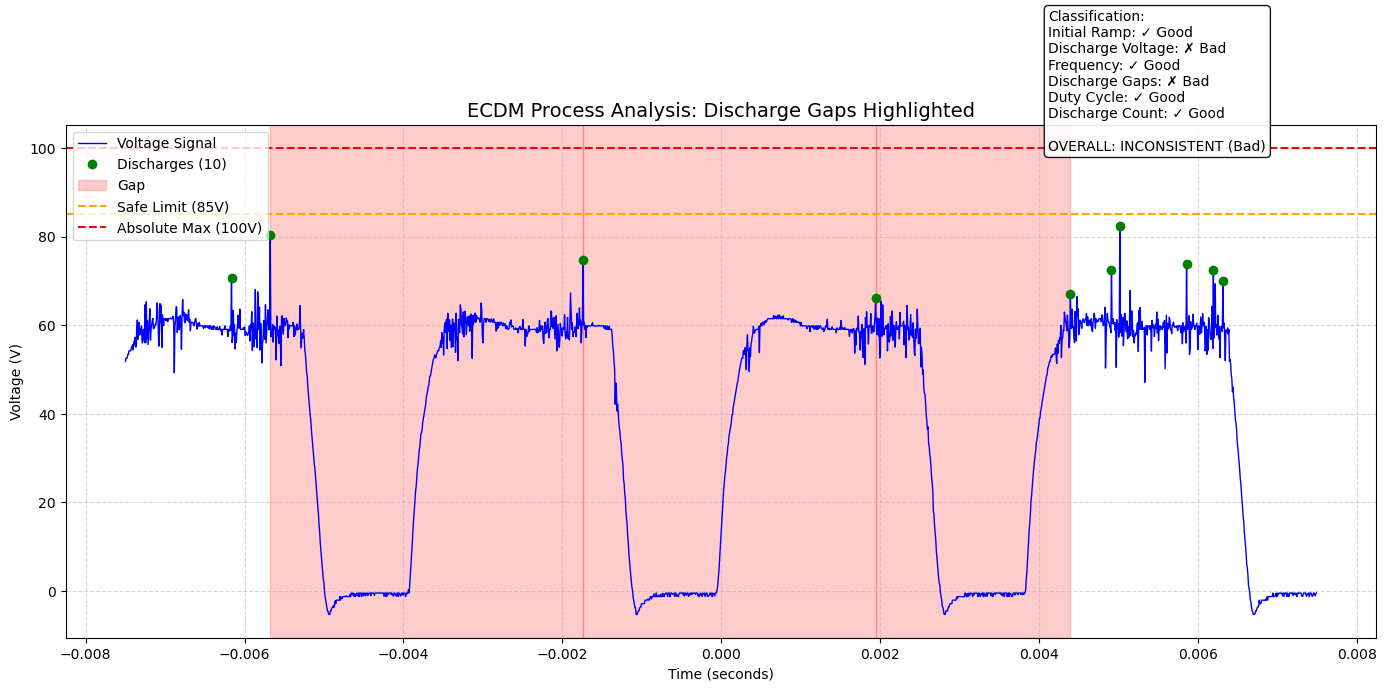


ANALYSIS RESULTS:
Discharges: 10
Max Voltage: 82.49V
Frequency: 721.15Hz
Gaps Detected: 3

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✗ Bad
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: INCONSISTENT (Bad)


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def detect_discharge_gaps(time, peaks, max_gap=0.002):
    """Detect time gaps between consecutive discharges (sparks)."""
    if len(peaks) < 2:
        return []
    intervals = np.diff(time[peaks])
    gap_indices = np.where(intervals > max_gap)[0]
    return [(peaks[i], peaks[i+1]) for i in gap_indices]  # Return (start, end) indices of gaps

def classify_ecdm(stats, time, voltage, peaks):
    """Classification with discharge gap checks."""
    classifications = []
    
    # 1. Initial Curve Check
    initial_slope = np.polyfit(np.linspace(0, 1, 100), stats['voltage'][:100], 1)[0]
    classifications.append(('Initial Ramp', 'Good' if initial_slope > 2 else 'Bad'))
    
    # 2. Discharge Voltage
    classifications.append(('Discharge Voltage', 
                          'Good' if 40 <= stats['max_voltage'] <= 80 else 'Bad'))
    
    # 3. Frequency
    classifications.append(('Frequency', 
                          'Good' if 100 <= stats['frequency'] <= 3000 else 'Bad'))
    
    # 4. Discharge Gaps (critical fix: now checks time between peaks)
    gaps = detect_discharge_gaps(time, peaks)
    classifications.append(('Discharge Gaps', 
                          'Bad' if gaps else 'Good'))
    
    # 5. Duty Cycle
    classifications.append(('Duty Cycle', 
                          'Good' if 30 <= stats['duty_cycle'] <= 70 else 'Bad'))
    
    # 6. Discharge Count
    classifications.append(('Discharge Count', 
                          'Good' if stats['discharges'] > 5 else 'Bad'))
    
    # Overall classification
    good_count = sum(1 for _, status in classifications if status == 'Good')
    overall = 'CONSISTENT (Good)' if good_count >= 5 else 'INCONSISTENT (Bad)'
    
    return classifications, overall, gaps

def analyze_ecdm_process(csv_file, max_gap=0.002):
    """Final corrected version with accurate gap highlighting."""
    try:
        data = pd.read_csv(csv_file, header=None).apply(pd.to_numeric, errors='coerce').dropna()
        time = data.iloc[:, 0].values
        voltage = data.iloc[:, 1].values
        
        # Find discharges (sparks)
        peaks, _ = find_peaks(voltage, height=20, prominence=15, distance=10)
        
        stats = {
            'voltage': voltage,
            'discharges': len(peaks),
            'max_voltage': np.max(voltage),
            'frequency': 1/np.mean(np.diff(time[peaks])) if len(peaks) > 1 else 0,
            'duty_cycle': 100 * np.sum(voltage > (0.5 * np.max(voltage))) / len(voltage)
        }
        
        # Classify and get gap locations
        classifications, overall, gaps = classify_ecdm(stats, time, voltage, peaks)
        
        # Visualization
        plt.figure(figsize=(14, 7))
        plt.plot(time, voltage, 'b-', linewidth=1, label='Voltage Signal')
        plt.plot(time[peaks], voltage[peaks], 'go', markersize=6, label=f'Discharges ({stats["discharges"]})')
        
        # Highlight gaps BETWEEN discharges (sparks)
        for start, end in gaps:
            plt.axvspan(time[start], time[end], color='red', alpha=0.2, label='Gap' if start == gaps[0][0] else "")
        
        plt.axhline(85, color='orange', linestyle='--', label='Safe Limit (85V)')
        plt.axhline(100, color='red', linestyle='--', label='Absolute Max (100V)')
        
        # Add classification
        class_text = "\n".join([f"{name}: {'✓' if status == 'Good' else '✗'} {status}" 
                              for name, status in classifications])
        plt.annotate(f"Classification:\n{class_text}\n\nOVERALL: {overall}",
                    xy=(0.75, 0.95), xycoords='axes fraction',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                    fontsize=10)
        
        plt.xlabel('Time (seconds)')
        plt.ylabel('Voltage (V)')
        plt.title('ECDM Process Analysis: Discharge Gaps Highlighted', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Console output
        print("\n" + "="*50)
        print("ANALYSIS RESULTS:")
        print(f"Discharges: {stats['discharges']}")
        print(f"Max Voltage: {stats['max_voltage']:.2f}V")
        print(f"Frequency: {stats['frequency']:.2f}Hz")
        print(f"Gaps Detected: {len(gaps)}")
        
        print("\nCLASSIFICATION:")
        for name, status in classifications:
            print(f"{name:20}: {'✓' if status == 'Good' else '✗'} {status}")
        print(f"\n\033[1mOVERALL: {overall}\033[0m")
        print("="*50)
        
        return {**stats, 'gaps': gaps, 'classification': classifications, 'overall': overall}
        
    except Exception as e:
        print(f"\nERROR: {str(e)}")
        return None

# Example usage
results = analyze_ecdm_process(r"C:\ECDM project\sample\v1.csv", max_gap=0.002)


Processing: sahil11.csv


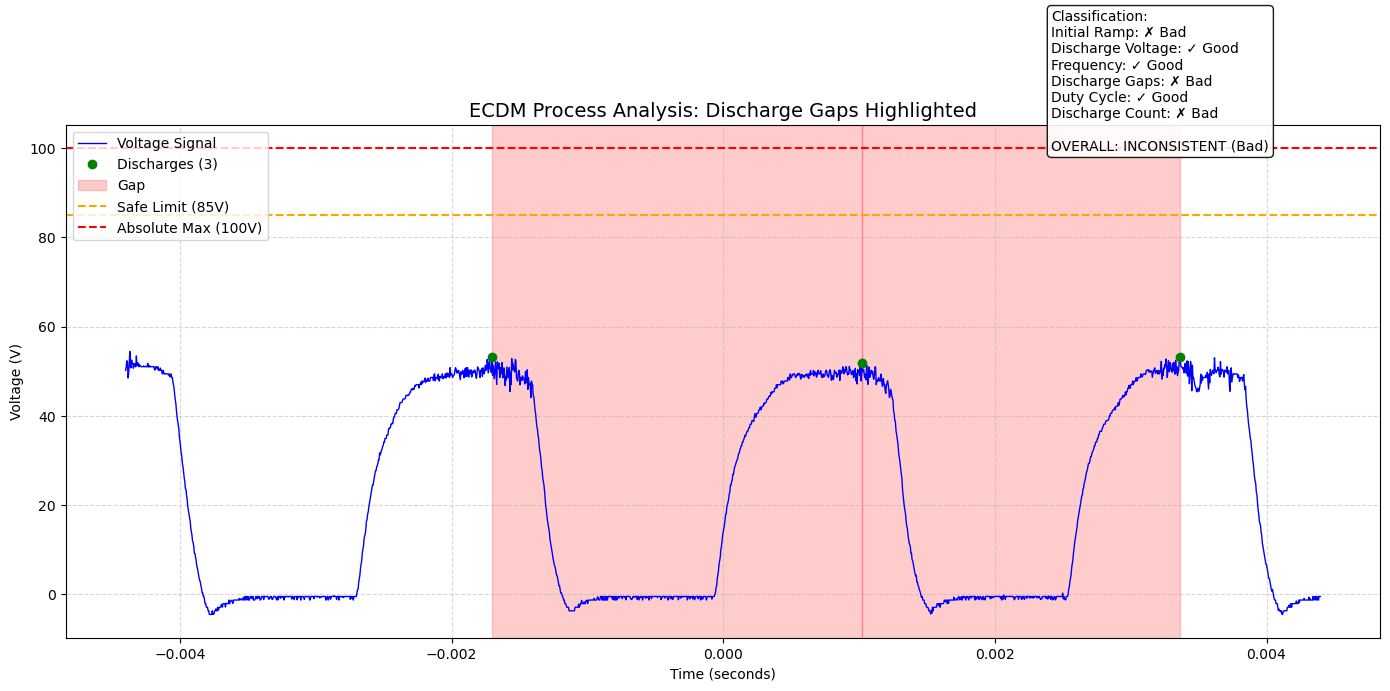


ANALYSIS RESULTS:
Discharges: 3
Max Voltage: 54.43V
Frequency: 394.91Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil14.csv


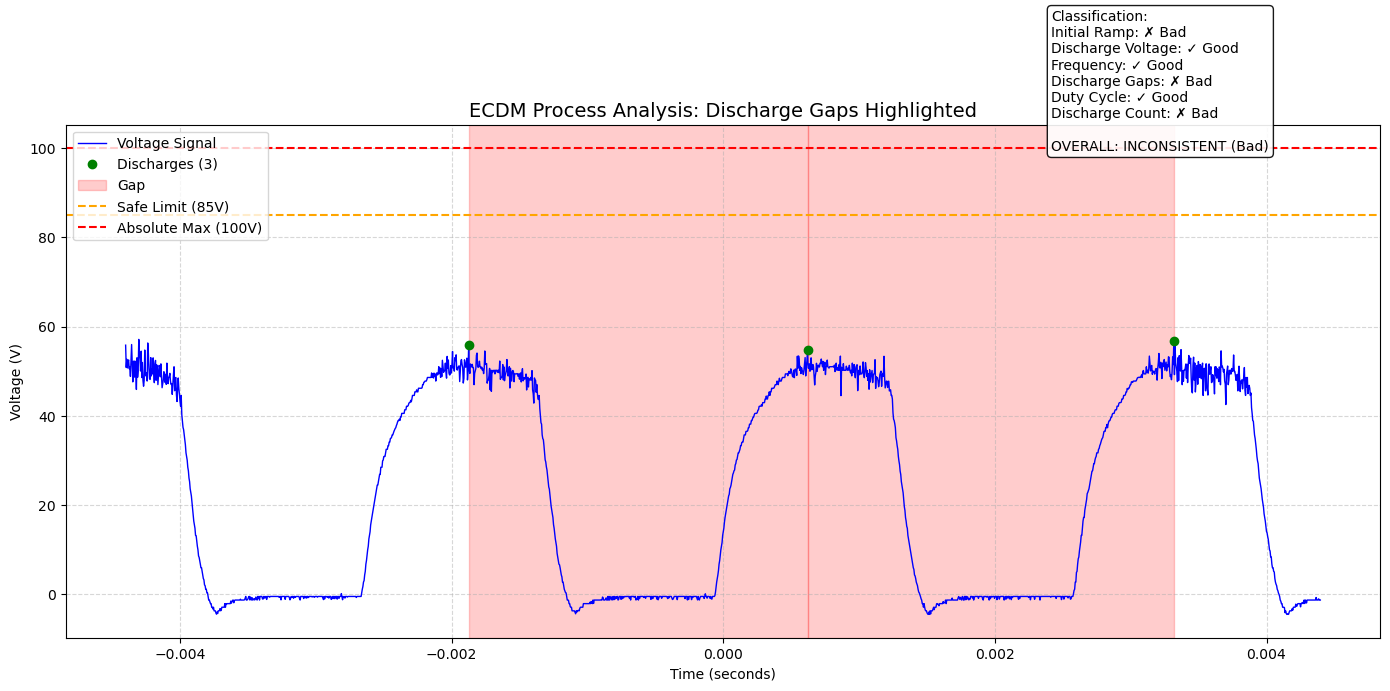


ANALYSIS RESULTS:
Discharges: 3
Max Voltage: 57.13V
Frequency: 385.21Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil17.csv


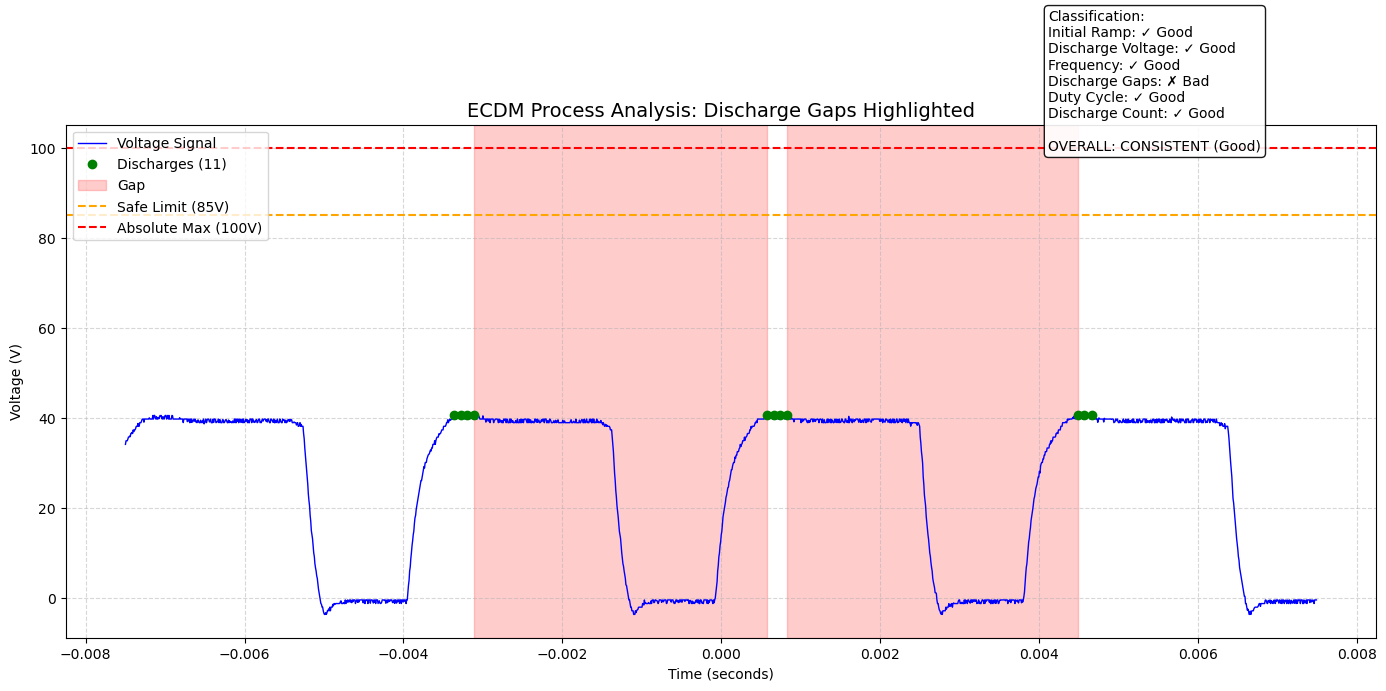


ANALYSIS RESULTS:
Discharges: 11
Max Voltage: 40.55V
Frequency: 1246.11Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: CONSISTENT (Good)
Overall: CONSISTENT (Good)

Processing: sahil2.csv


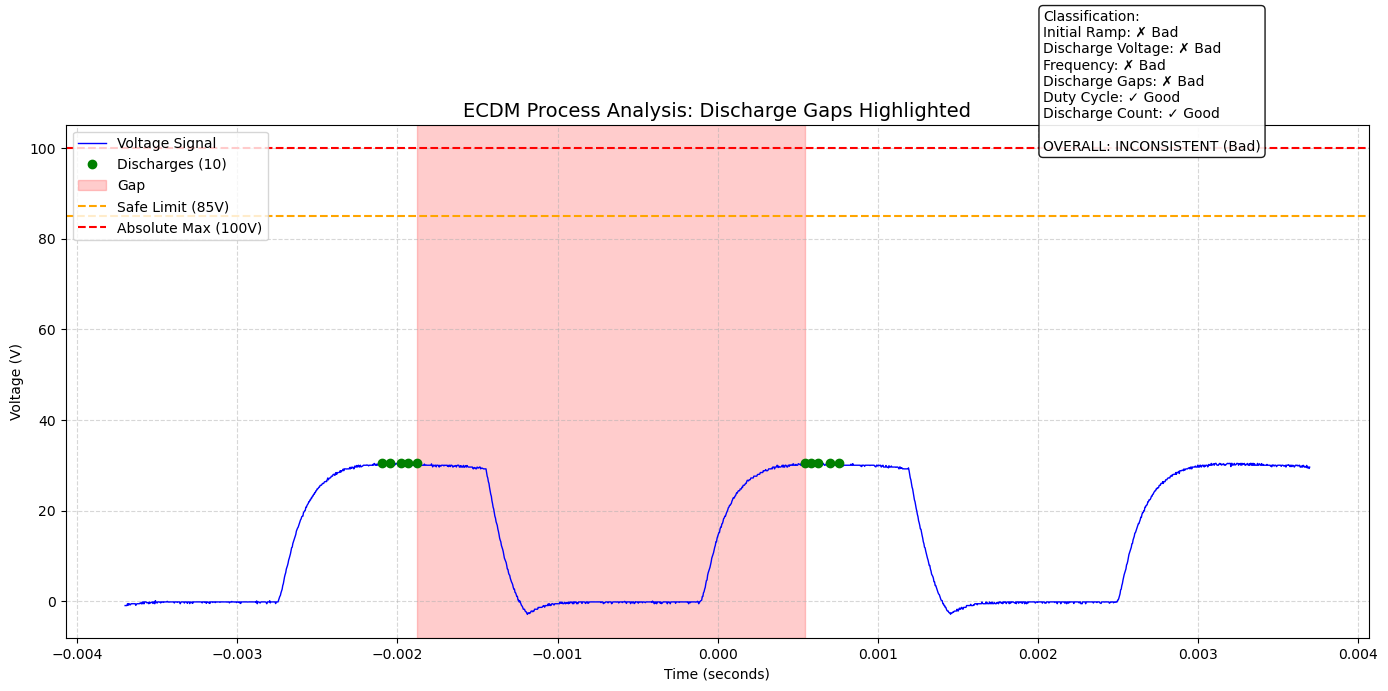


ANALYSIS RESULTS:
Discharges: 10
Max Voltage: 30.42V
Frequency: 3154.91Hz
Gaps Detected: 1

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✗ Bad
Frequency           : ✗ Bad
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil20.csv


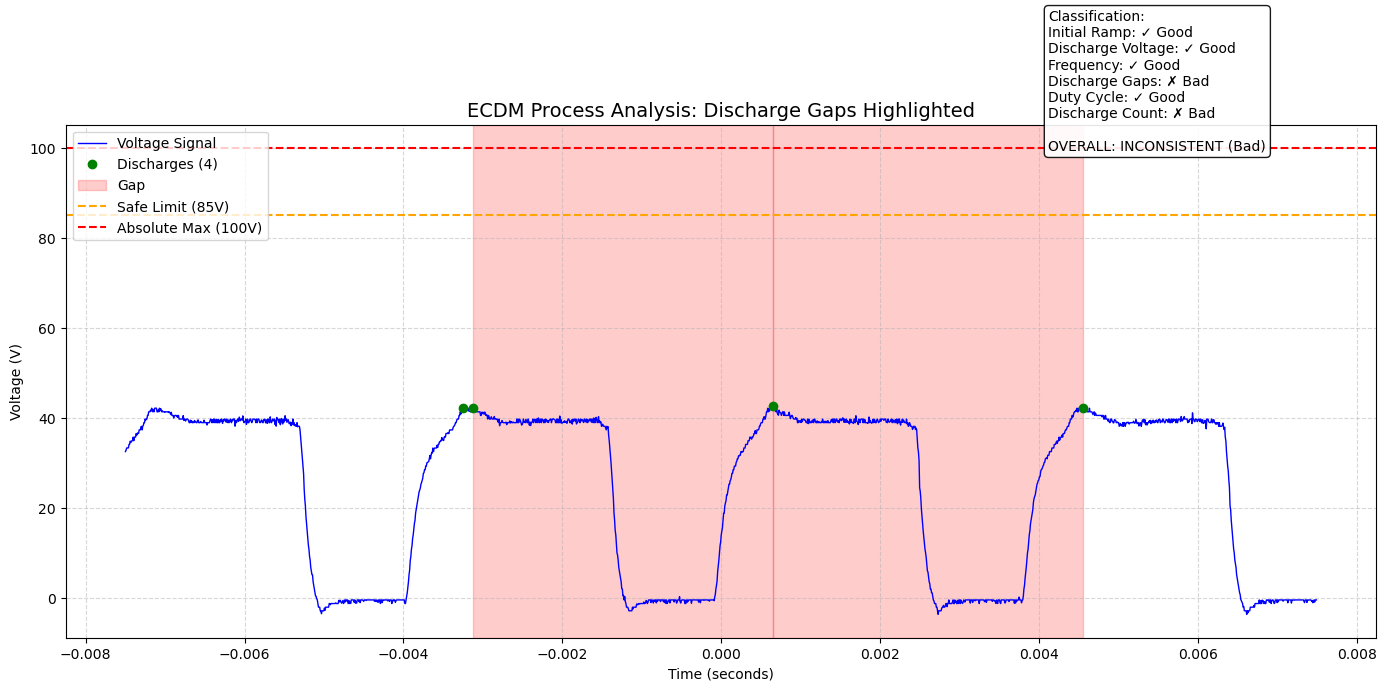


ANALYSIS RESULTS:
Discharges: 4
Max Voltage: 42.60V
Frequency: 384.62Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil23.csv


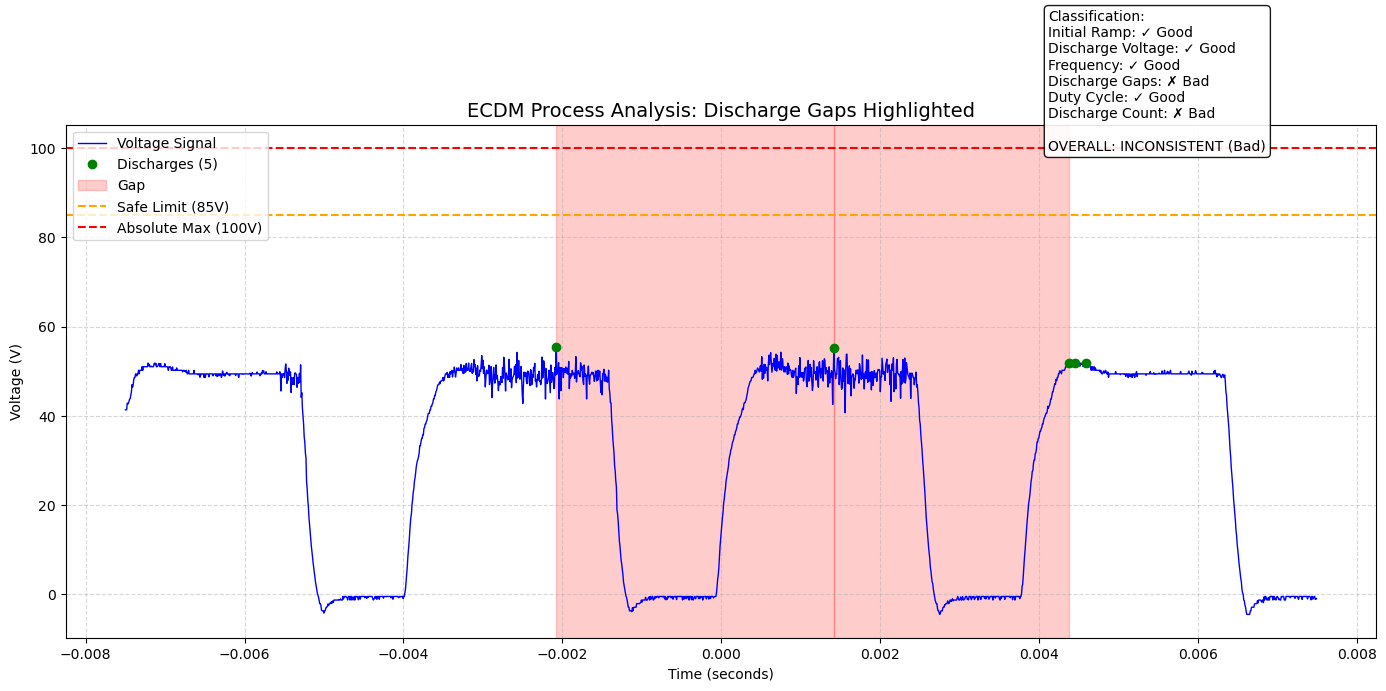


ANALYSIS RESULTS:
Discharges: 5
Max Voltage: 55.33V
Frequency: 599.25Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil26.csv


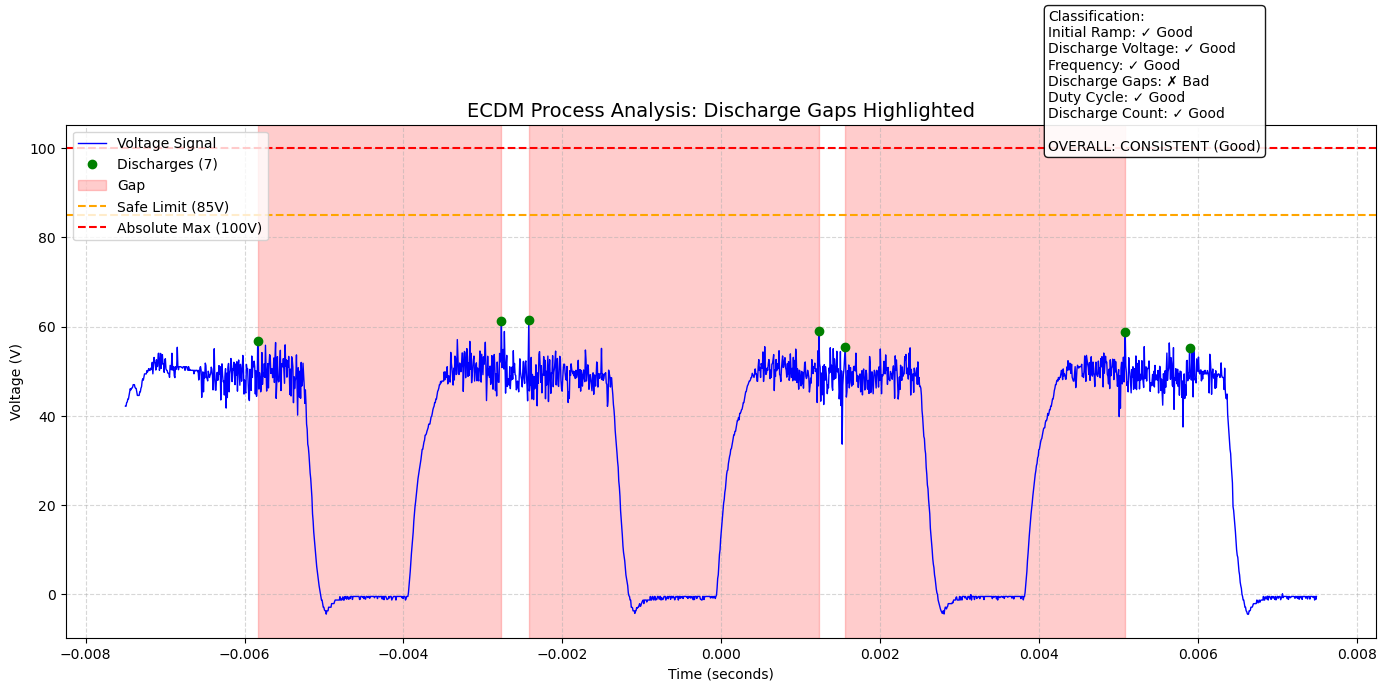


ANALYSIS RESULTS:
Discharges: 7
Max Voltage: 61.55V
Frequency: 511.51Hz
Gaps Detected: 3

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: CONSISTENT (Good)
Overall: CONSISTENT (Good)

Processing: sahil29.csv


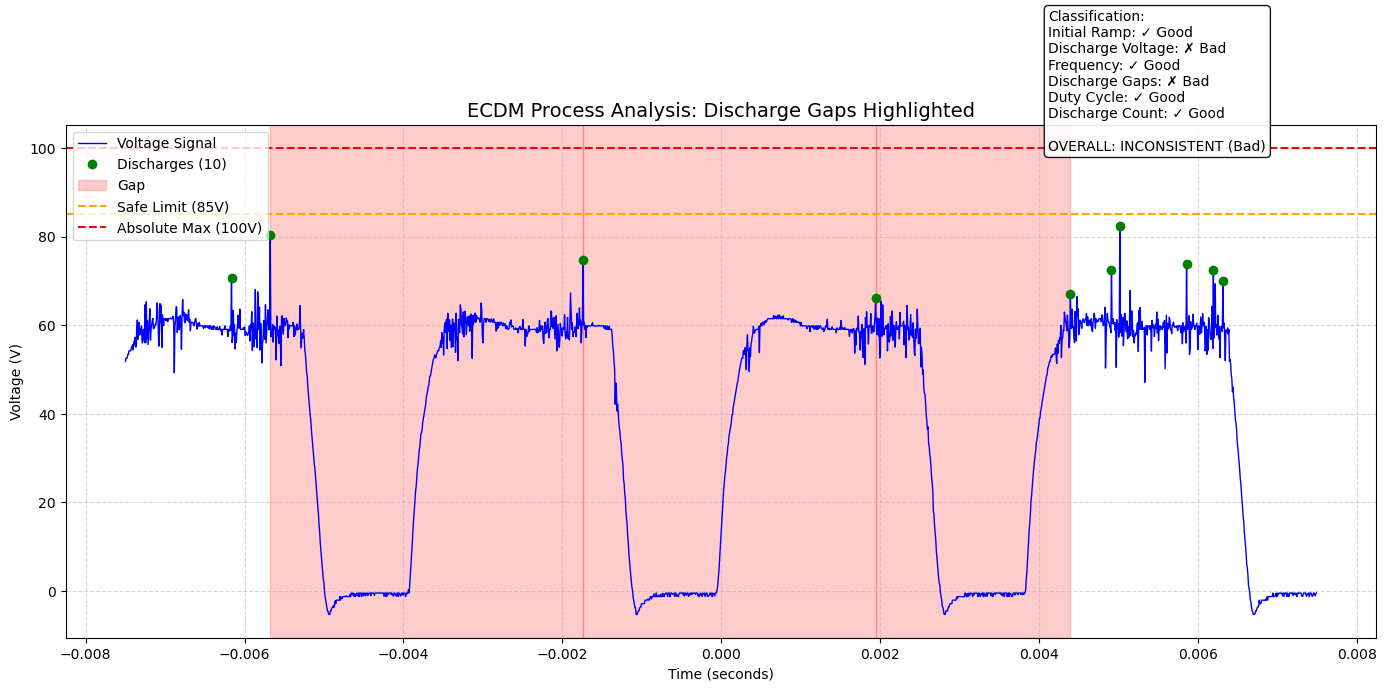


ANALYSIS RESULTS:
Discharges: 10
Max Voltage: 82.49V
Frequency: 721.15Hz
Gaps Detected: 3

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✗ Bad
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil32.csv


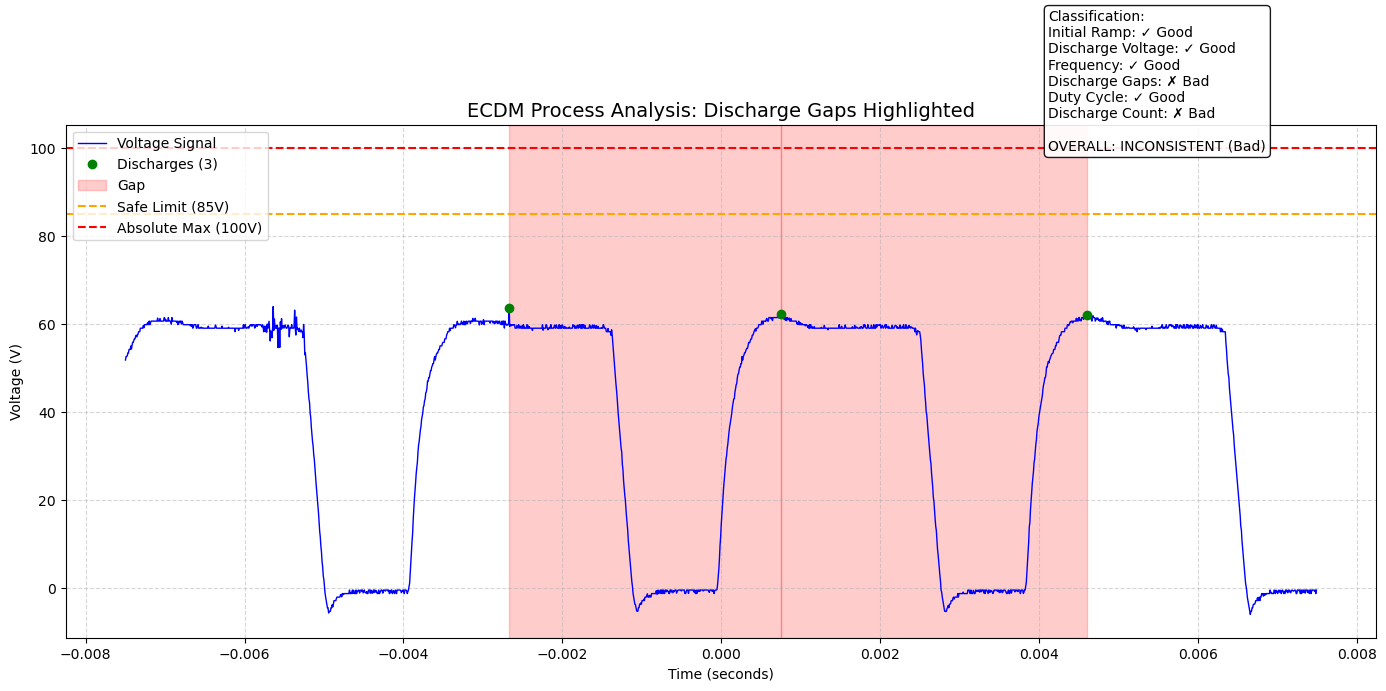


ANALYSIS RESULTS:
Discharges: 3
Max Voltage: 63.97V
Frequency: 274.91Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil4.csv


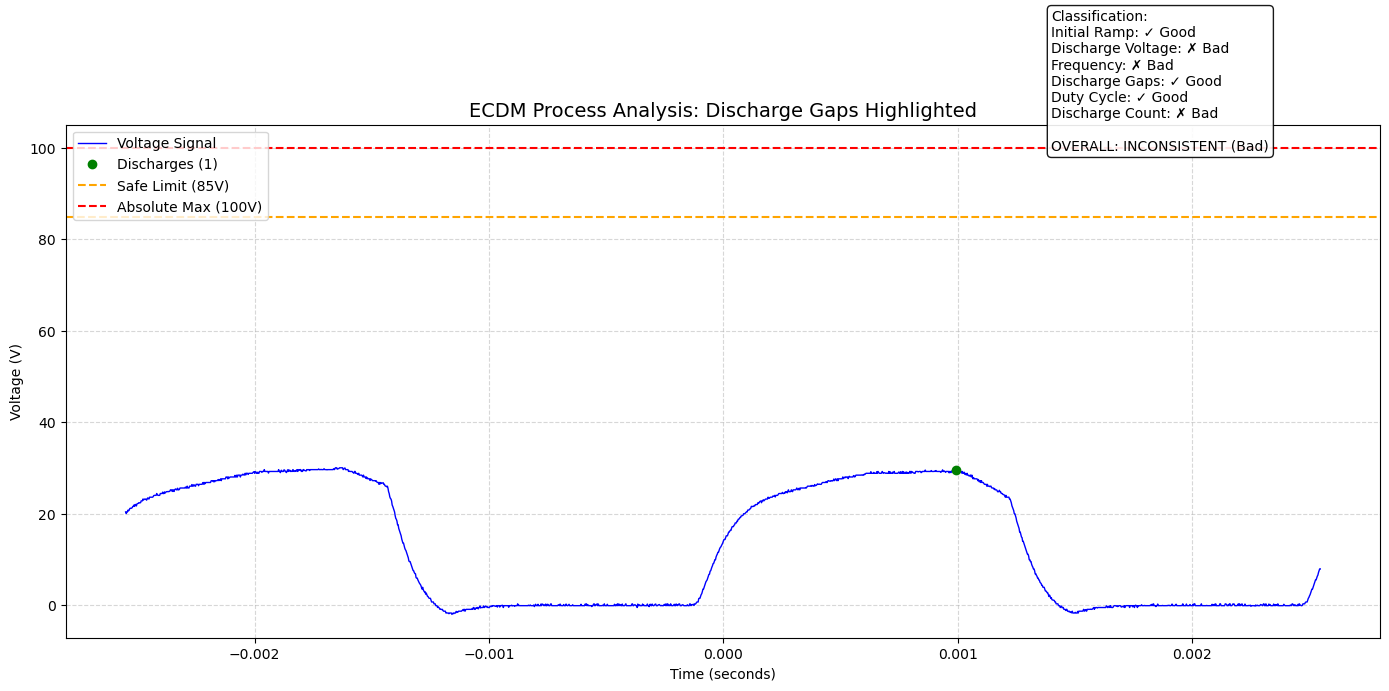


ANALYSIS RESULTS:
Discharges: 1
Max Voltage: 30.07V
Frequency: 0.00Hz
Gaps Detected: 0

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✗ Bad
Frequency           : ✗ Bad
Discharge Gaps      : ✓ Good
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil6.csv


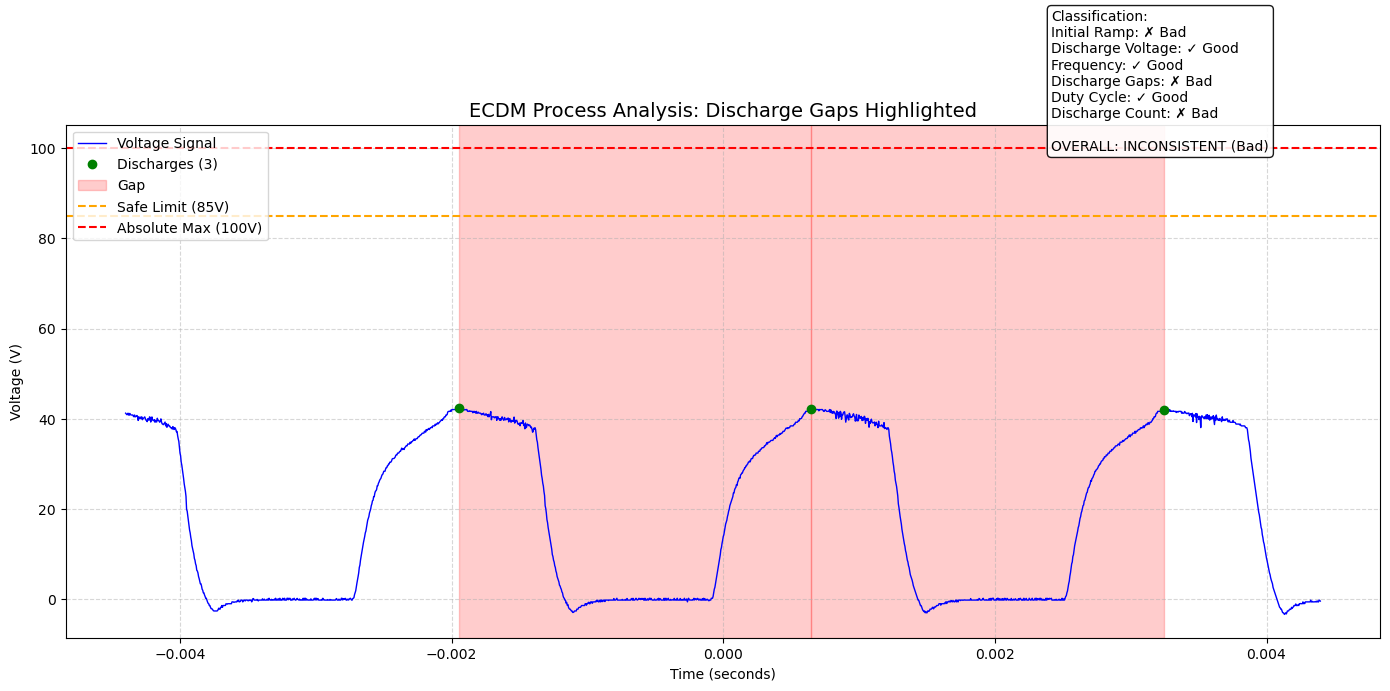


ANALYSIS RESULTS:
Discharges: 3
Max Voltage: 42.44V
Frequency: 385.21Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: sahil8.csv


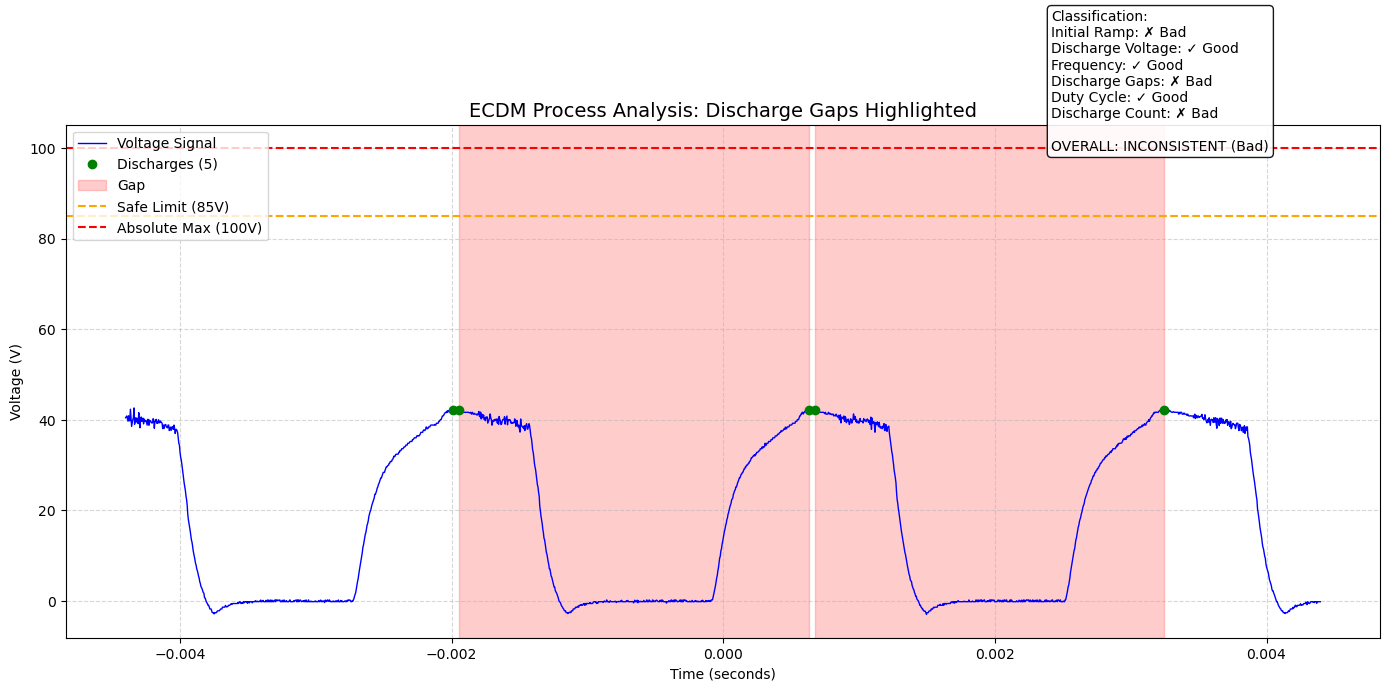


ANALYSIS RESULTS:
Discharges: 5
Max Voltage: 42.61V
Frequency: 763.30Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_12.csv


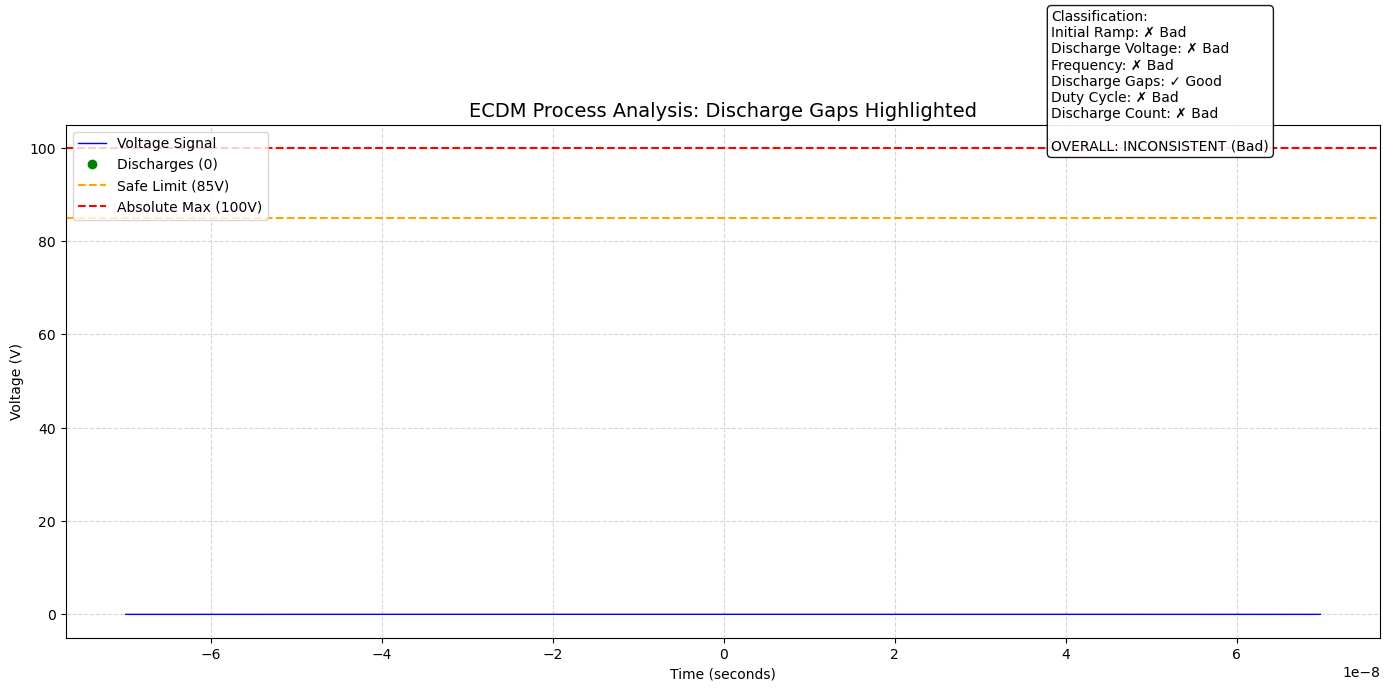


ANALYSIS RESULTS:
Discharges: 0
Max Voltage: -0.00V
Frequency: 0.00Hz
Gaps Detected: 0

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✗ Bad
Frequency           : ✗ Bad
Discharge Gaps      : ✓ Good
Duty Cycle          : ✗ Bad
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_15.csv


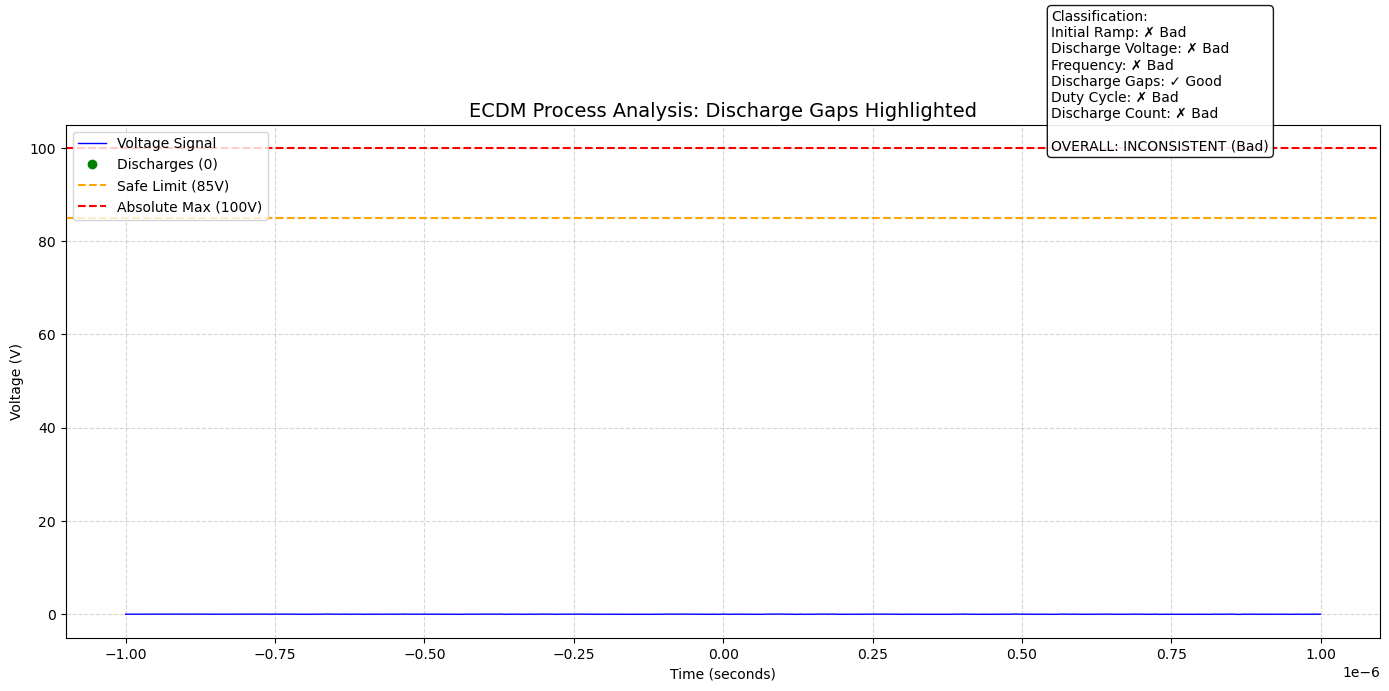


ANALYSIS RESULTS:
Discharges: 0
Max Voltage: 0.02V
Frequency: 0.00Hz
Gaps Detected: 0

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✗ Bad
Frequency           : ✗ Bad
Discharge Gaps      : ✓ Good
Duty Cycle          : ✗ Bad
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_18.csv


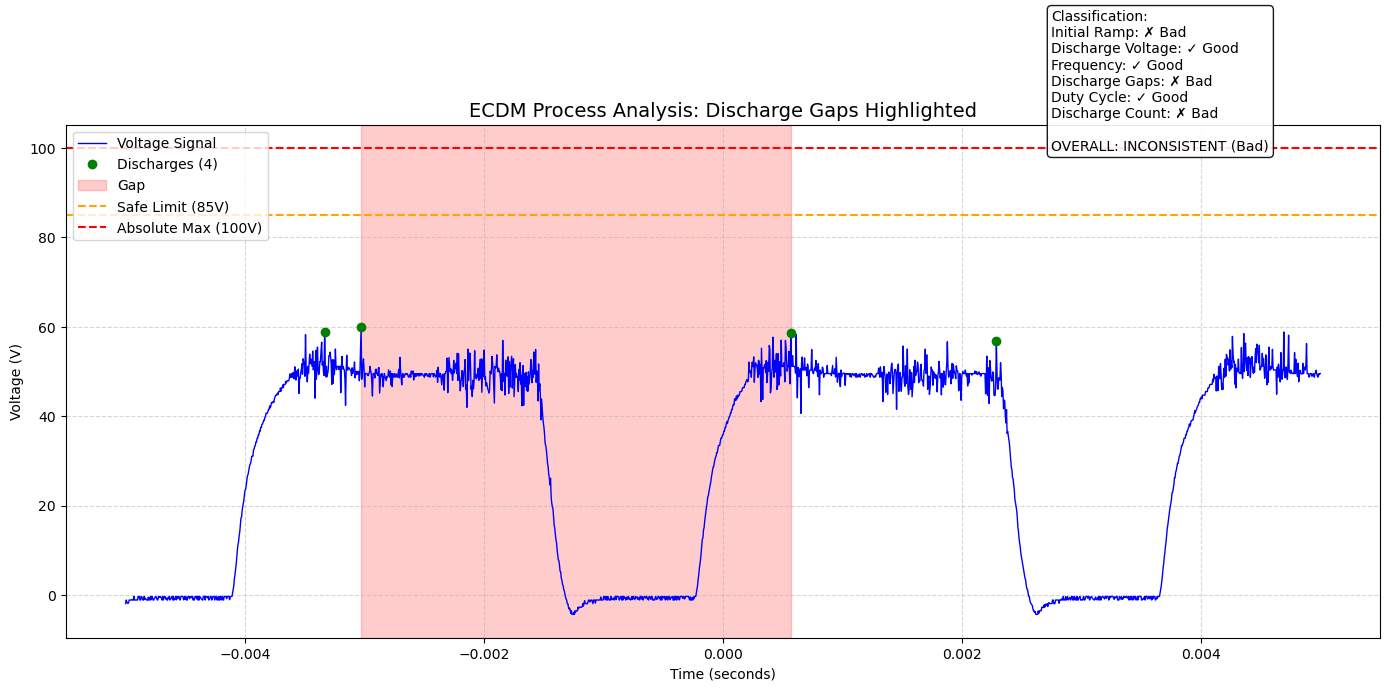


ANALYSIS RESULTS:
Discharges: 4
Max Voltage: 59.92V
Frequency: 533.81Hz
Gaps Detected: 1

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_2.csv


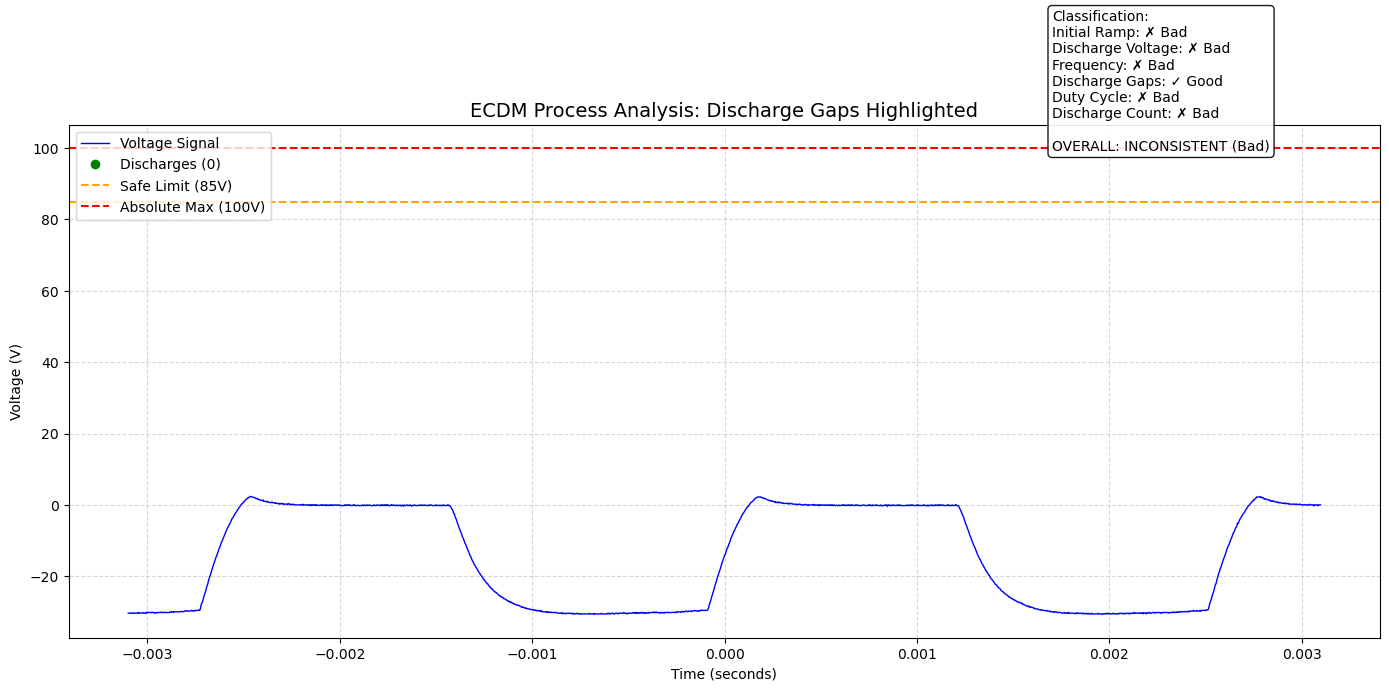


ANALYSIS RESULTS:
Discharges: 0
Max Voltage: 2.40V
Frequency: 0.00Hz
Gaps Detected: 0

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✗ Bad
Frequency           : ✗ Bad
Discharge Gaps      : ✓ Good
Duty Cycle          : ✗ Bad
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_21.csv


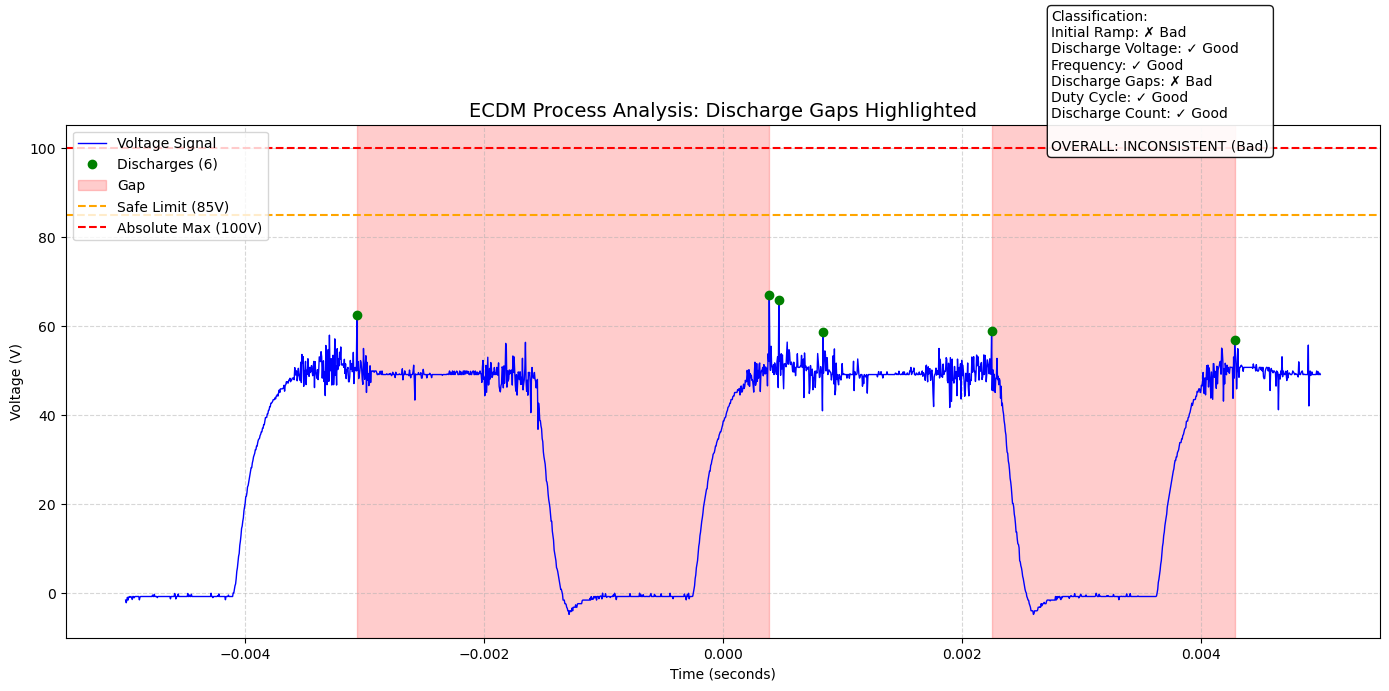


ANALYSIS RESULTS:
Discharges: 6
Max Voltage: 67.06V
Frequency: 680.74Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_24.csv


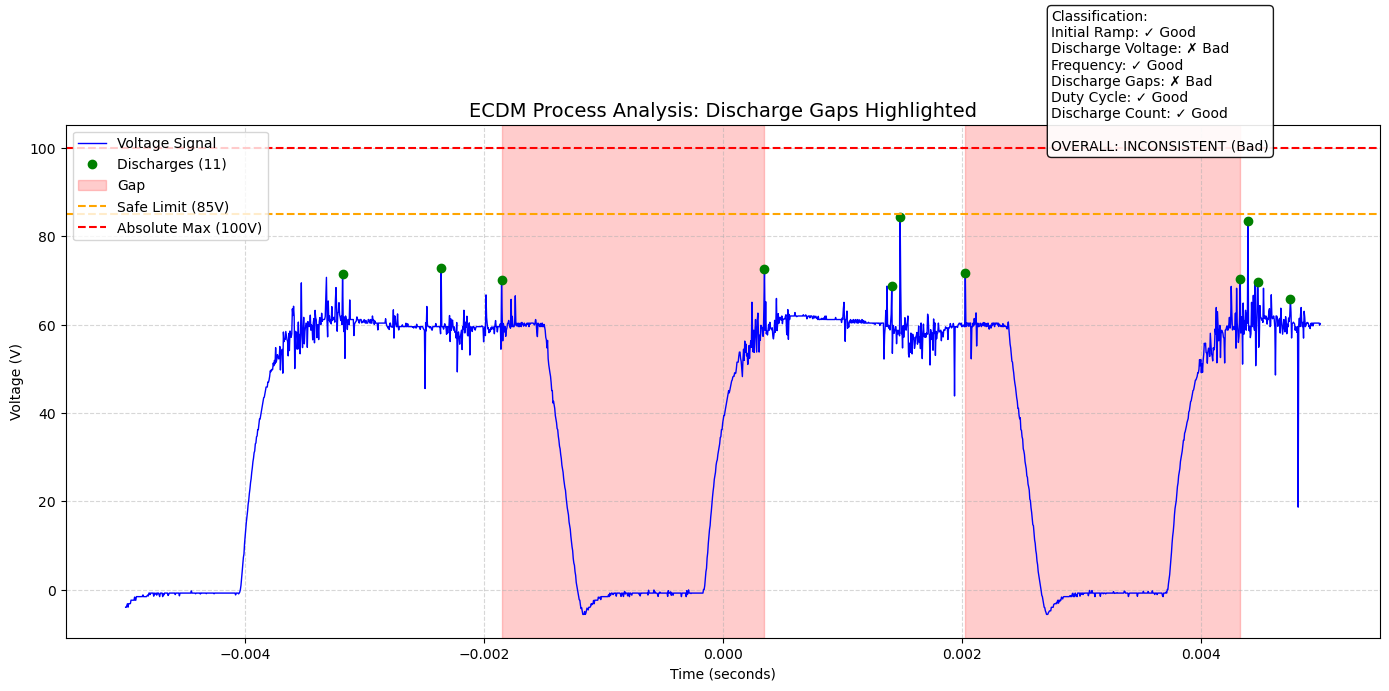


ANALYSIS RESULTS:
Discharges: 11
Max Voltage: 84.31V
Frequency: 1261.03Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✗ Bad
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_27.csv


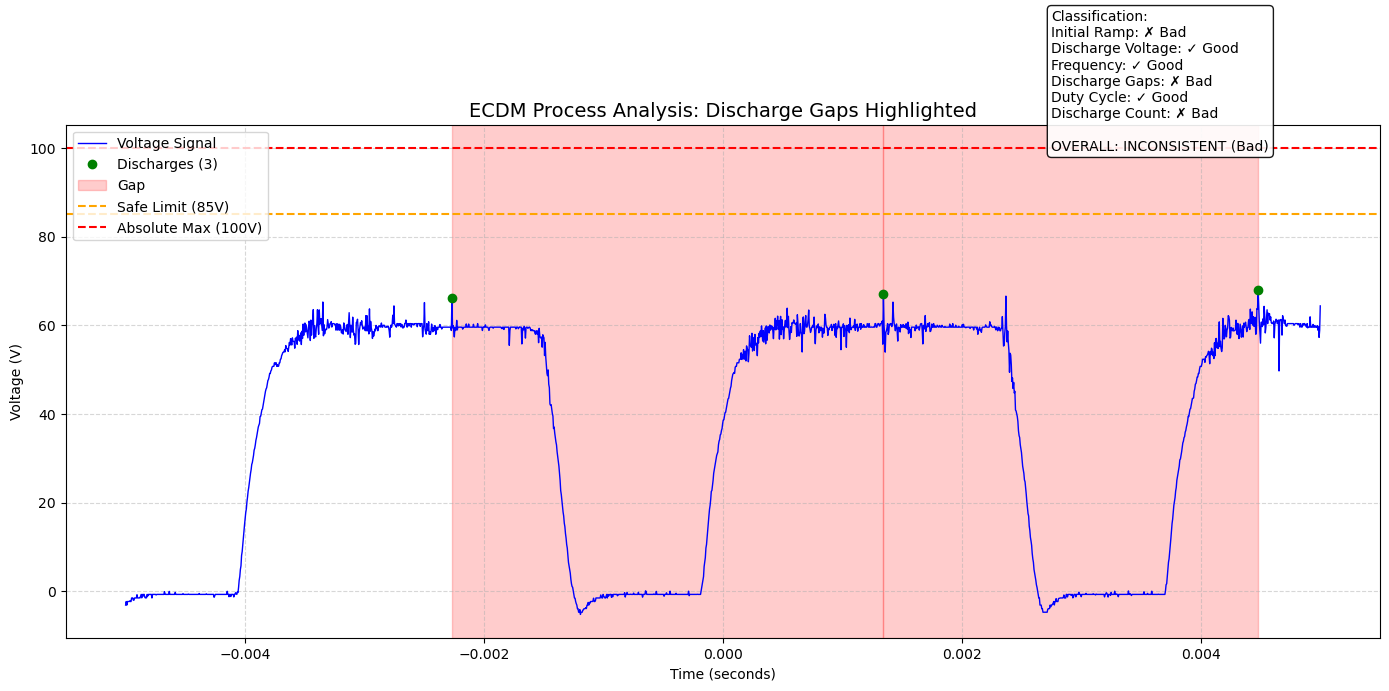


ANALYSIS RESULTS:
Discharges: 3
Max Voltage: 68.02V
Frequency: 296.52Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✗ Bad
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_6.csv


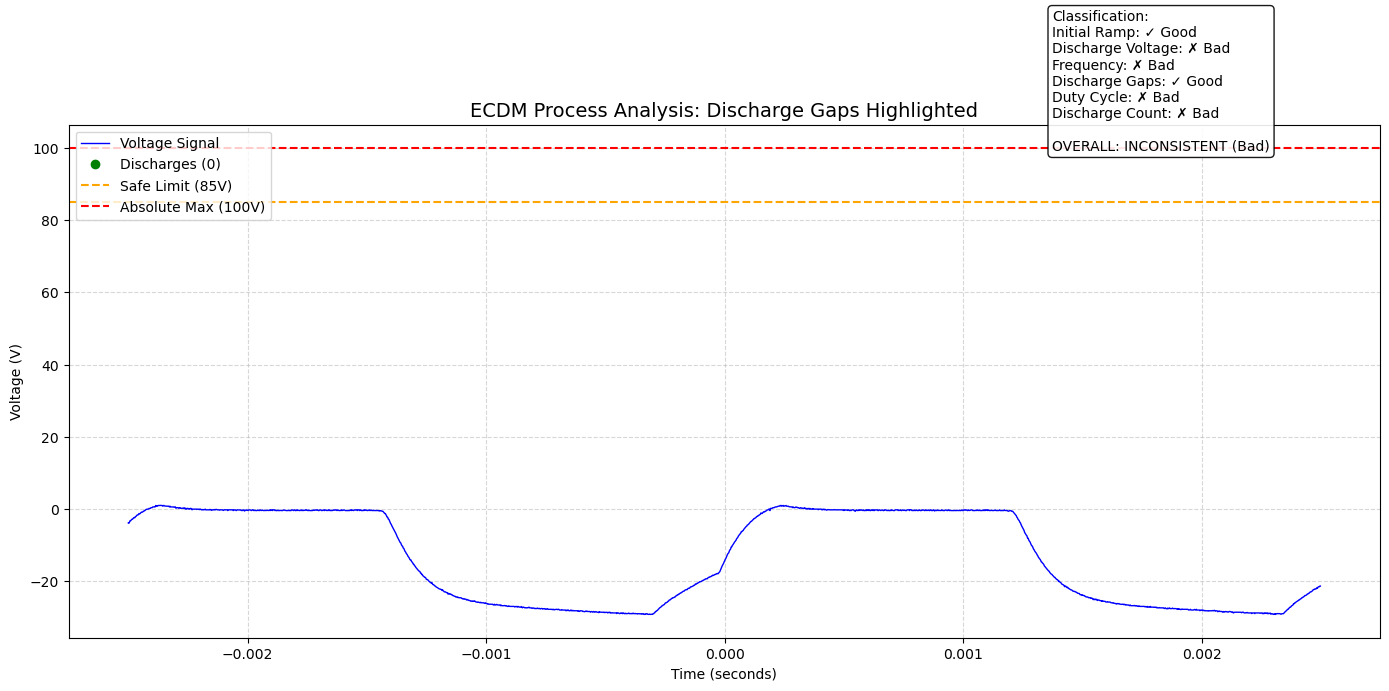


ANALYSIS RESULTS:
Discharges: 0
Max Voltage: 1.06V
Frequency: 0.00Hz
Gaps Detected: 0

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✗ Bad
Frequency           : ✗ Bad
Discharge Gaps      : ✓ Good
Duty Cycle          : ✗ Bad
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: scope_8.csv


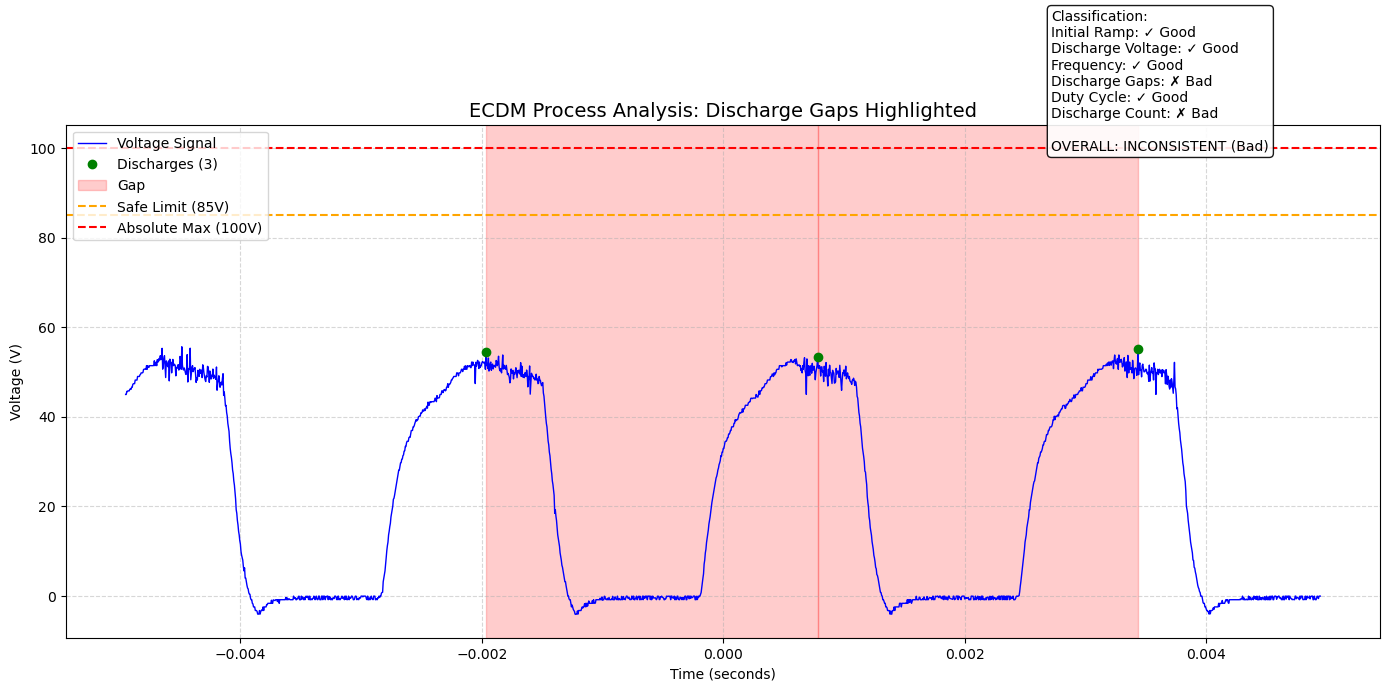


ANALYSIS RESULTS:
Discharges: 3
Max Voltage: 55.61V
Frequency: 370.34Hz
Gaps Detected: 2

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✗ Bad

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: V1.csv


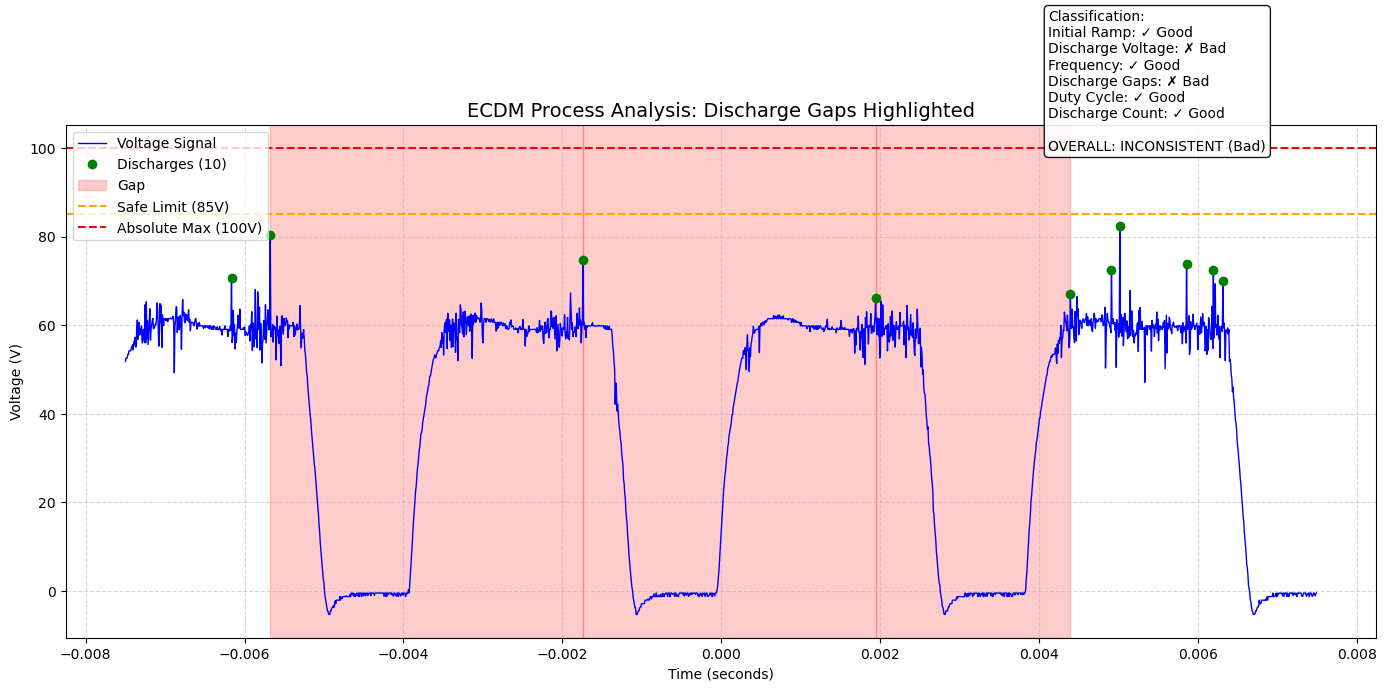


ANALYSIS RESULTS:
Discharges: 10
Max Voltage: 82.49V
Frequency: 721.15Hz
Gaps Detected: 3

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✗ Bad
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: INCONSISTENT (Bad)
Overall: INCONSISTENT (Bad)

Processing: V2.csv


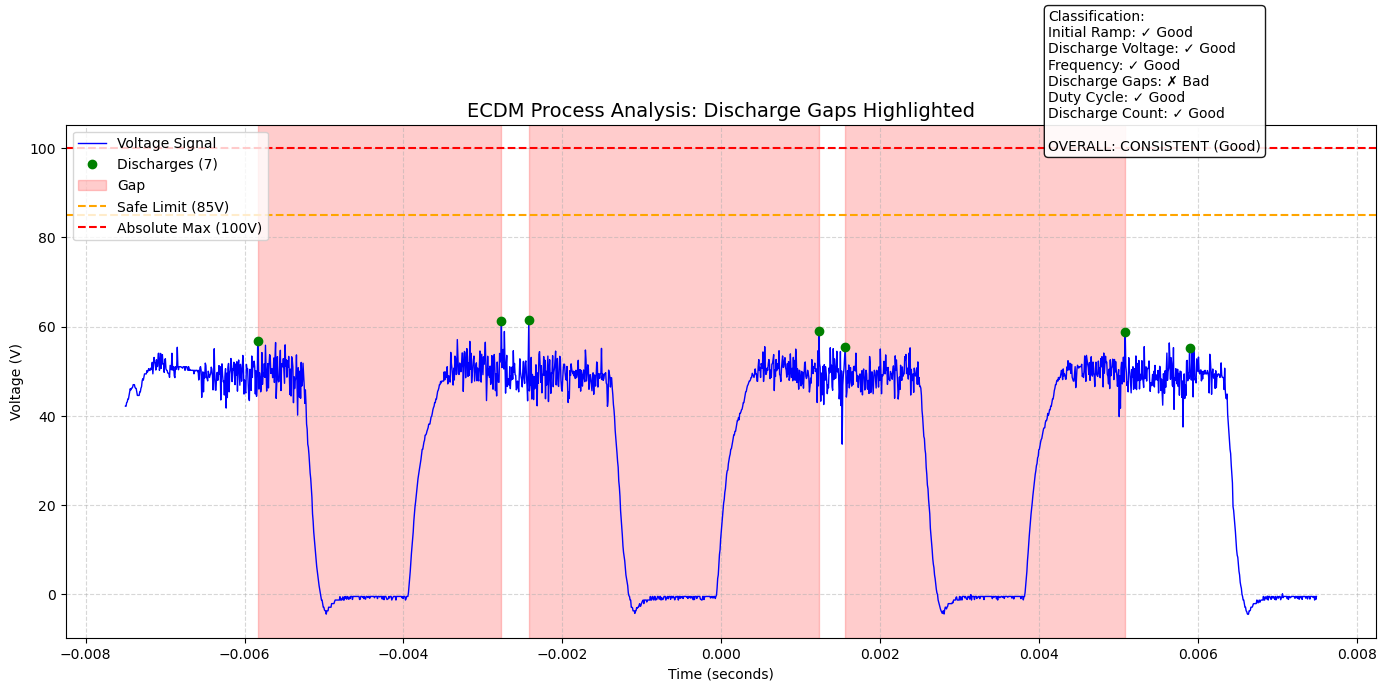


ANALYSIS RESULTS:
Discharges: 7
Max Voltage: 61.55V
Frequency: 511.51Hz
Gaps Detected: 3

CLASSIFICATION:
Initial Ramp        : ✓ Good
Discharge Voltage   : ✓ Good
Frequency           : ✓ Good
Discharge Gaps      : ✗ Bad
Duty Cycle          : ✓ Good
Discharge Count     : ✓ Good

OVERALL: CONSISTENT (Good)
Overall: CONSISTENT (Good)

Final Labels:
{'sahil11.csv': 0, 'sahil14.csv': 0, 'sahil17.csv': 1, 'sahil2.csv': 0, 'sahil20.csv': 0, 'sahil23.csv': 0, 'sahil26.csv': 1, 'sahil29.csv': 0, 'sahil32.csv': 0, 'sahil4.csv': 0, 'sahil6.csv': 0, 'sahil8.csv': 0, 'scope_12.csv': 0, 'scope_15.csv': 0, 'scope_18.csv': 0, 'scope_2.csv': 0, 'scope_21.csv': 0, 'scope_24.csv': 0, 'scope_27.csv': 0, 'scope_6.csv': 0, 'scope_8.csv': 0, 'V1.csv': 0, 'V2.csv': 1}


In [9]:
import os

folder = r"C:\ECDM project\sample"

labels = {}

for file in os.listdir(folder):
    if file.endswith(".csv"):
        path = os.path.join(folder, file)
        
        print(f"\nProcessing: {file}")
        result = analyze_ecdm_process(path)
        
        if result is not None:
            print("Overall:", result['overall'])
            
            # 🔥 FIXED LOGIC
            if "INCONSISTENT" in result['overall']:
                labels[file] = 0   # Unstable
            else:
                labels[file] = 1   # Stable

print("\nFinal Labels:")
print(labels)


In [10]:
import pandas as pd
import numpy as np
import os
from scipy.signal import find_peaks

folder = r"C:\ECDM project\sample"

# Your labels dictionary (paste your final labels here)
labels = {
'sahil11.csv': 0, 'sahil14.csv': 0, 'sahil17.csv': 1, 'sahil2.csv': 0,
'sahil20.csv': 0, 'sahil23.csv': 0, 'sahil26.csv': 1, 'sahil29.csv': 0,
'sahil32.csv': 0, 'sahil4.csv': 0, 'sahil6.csv': 0, 'sahil8.csv': 0,
'scope_12.csv': 0, 'scope_15.csv': 0, 'scope_18.csv': 0, 'scope_2.csv': 0,
'scope_21.csv': 0, 'scope_24.csv': 1, 'scope_27.csv': 0, 'scope_6.csv': 0,
'scope_8.csv': 0, 'V1.csv': 0, 'V2.csv': 1
}

dataset = []

for file in os.listdir(folder):
    if file.endswith(".csv") and file in labels:
        path = os.path.join(folder, file)

        # Skip header + unit rows (VERY IMPORTANT for your data)
        df = pd.read_csv(path, skiprows=2, header=None)
        df = df.apply(pd.to_numeric, errors='coerce').dropna()

        time = df.iloc[:, 0].values
        voltage = df.iloc[:, 1].values

        # Peak detection (sparks)
        peaks, _ = find_peaks(voltage, height=20, prominence=15, distance=10)

        # Feature extraction
        max_voltage = np.max(voltage)
        mean_voltage = np.mean(voltage)
        std_voltage = np.std(voltage)
        discharge_count = len(peaks)

        frequency = 1/np.mean(np.diff(time[peaks])) if len(peaks) > 1 else 0
        duty_cycle = 100 * np.sum(voltage > (0.5 * max_voltage)) / len(voltage)

        # Gap feature
        if len(peaks) > 1:
            intervals = np.diff(time[peaks])
            max_gap = np.max(intervals)
            gap_std = np.std(intervals)
        else:
            max_gap = 0
            gap_std = 0

        dataset.append({
            "file": file,
            "max_voltage": max_voltage,
            "mean_voltage": mean_voltage,
            "std_voltage": std_voltage,
            "discharge_count": discharge_count,
            "frequency": frequency,
            "duty_cycle": duty_cycle,
            "max_gap": max_gap,
            "gap_std": gap_std,
            "label": labels[file]
        })

# Create DataFrame
df_ml = pd.DataFrame(dataset)

print("ML Dataset Shape:", df_ml.shape)
df_ml.head()


ML Dataset Shape: (23, 10)


,file,max_voltage,mean_voltage,std_voltage,discharge_count,frequency,duty_cycle,max_gap,gap_std,label
0,sahil11.csv,54.432935,22.571150,23.017176,3,394.913514,46.95,0.002724,0.000191,0
1,sahil14.csv,57.125558,22.910476,23.226916,3,385.208012,46.55,0.002697,0.000101,0
2,sahil17.csv,40.554020,25.527015,18.162484,11,1246.105919,66.10,0.003683,0.001434,1
3,sahil2.csv,30.418342,14.187189,14.112226,10,3154.905879,48.80,0.002423,0.000745,0
4,sahil20.csv,42.596605,24.988569,18.291000,4,384.615385,64.40,0.003900,0.001749,0


In [15]:
print(df_ml.shape)
print(df_ml['label'].value_counts())
print(df_ml.head())


(23, 10)
label
0    19
1     4
Name: count, dtype: int64
          file  max_voltage  mean_voltage  std_voltage  discharge_count  \
0  sahil11.csv    54.432935     22.571150    23.017176                3   
1  sahil14.csv    57.125558     22.910476    23.226916                3   
2  sahil17.csv    40.554020     25.527015    18.162484               11   
3   sahil2.csv    30.418342     14.187189    14.112226               10   
4  sahil20.csv    42.596605     24.988569    18.291000                4   

     frequency  duty_cycle   max_gap   gap_std  label  
0   394.913514       46.95  0.002724  0.000191      0  
1   385.208012       46.55  0.002697  0.000101      0  
2  1246.105919       66.10  0.003683  0.001434      1  
3  3154.905879       48.80  0.002423  0.000745      0  
4   384.615385       64.40  0.003900  0.001749      0  


In [17]:
print("Missing Values Check:")
print(df_ml.isnull().sum())


Missing Values Check:
file               0
max_voltage        0
mean_voltage       0
std_voltage        0
discharge_count    0
frequency          0
duty_cycle         0
max_gap            0
gap_std            0
label              0
dtype: int64


In [19]:
print("Data Types:")
print(df_ml.dtypes)



Data Types:
file                object
max_voltage        float64
mean_voltage       float64
std_voltage        float64
discharge_count      int64
frequency          float64
duty_cycle         float64
max_gap            float64
gap_std            float64
label                int64
dtype: object


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Remove non-feature columns
X = df_ml.drop(columns=["file", "label"])  # Features
y = df_ml["label"]  # Target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# Scale features (important for frequency & gaps)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split (VERY IMPORTANT for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nTrain Class Distribution:")
print(y_train.value_counts())
print("\nTest Class Distribution:")
print(y_test.value_counts())

# Balanced Random Forest (KEY for your dataset)
model = RandomForestClassifier(
    n_estimators=600,
    max_depth=5,
    class_weight={0:1, 1:15},  # Manually boost stable class
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("\n Model Training Completed")


Feature Shape: (23, 8)
Target Shape: (23,)

Train Class Distribution:
label
0    13
1     3
Name: count, dtype: int64

Test Class Distribution:
label
0    6
1    1
Name: count, dtype: int64

 Model Training Completed


In [23]:
# Predictions
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
[[6 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         1

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5,
    scoring='f1'
)

print("Cross-validation F1 scores:", cv_scores)
print("Average F1 Score:", cv_scores.mean())


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cross-validation F1 scores: [0. 1. 0. 0. 1.]
Average F1 Score: 0.4


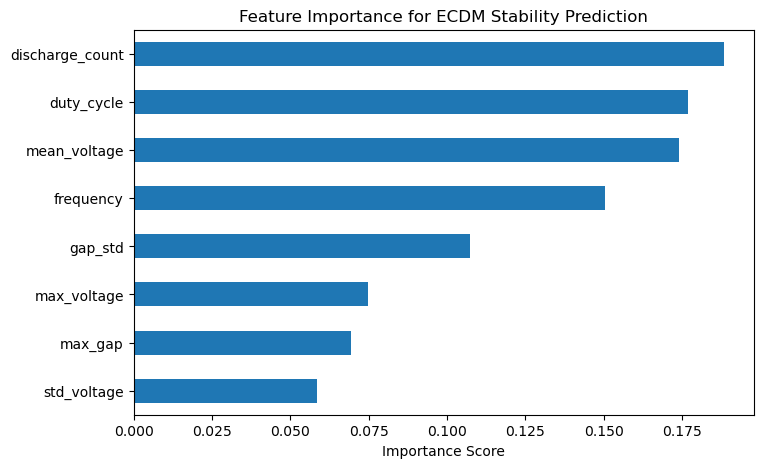

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Use original feature names (not scaled)
X_features = df_ml.drop(columns=["file", "label"])

importance = pd.Series(model.feature_importances_, index=X_features.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance for ECDM Stability Prediction")
plt.xlabel("Importance Score")
plt.show()


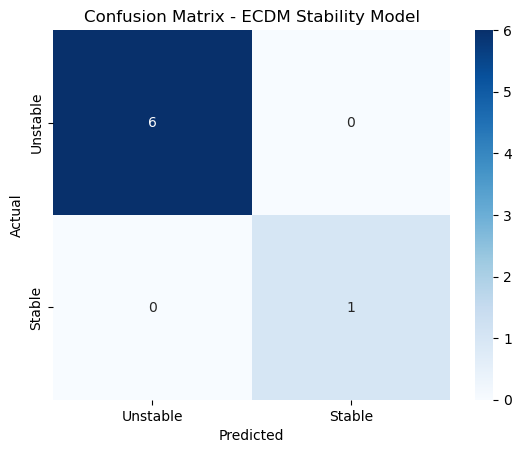

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unstable', 'Stable'],
            yticklabels=['Unstable', 'Stable'])
plt.title("Confusion Matrix - ECDM Stability Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use 3 folds (safe for 4 stable samples)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

accuracy_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=skf,
    scoring='accuracy'
)

f1_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=skf,
    scoring='f1'
)

f1_macro = cross_val_score(
    model,
    X_scaled,
    y,
    cv=skf,
    scoring='f1_macro'
)

print("Stratified 3-Fold Accuracy:", accuracy_scores)
print("Mean Accuracy:", accuracy_scores.mean())

print("\nStratified 3-Fold F1:", f1_scores)
print("Mean F1 Score:", f1_scores.mean())

print("Macro F1 Scores:", f1_macro)
print("Mean Macro F1:", f1_macro.mean())

Stratified 3-Fold Accuracy: [0.875      0.75       0.85714286]
Mean Accuracy: 0.8273809523809524

Stratified 3-Fold F1: [0. 0. 0.]
Mean F1 Score: 0.0
Macro F1 Scores: [0.46666667 0.42857143 0.46153846]
Mean Macro F1: 0.45225885225885226


In [33]:
# Check predictions on full dataset
y_pred_full = model.predict(X_scaled)

import numpy as np
print("Predicted class distribution:", np.bincount(y_pred_full))
print("Actual class distribution:", np.bincount(y))


Predicted class distribution: [19  4]
Actual class distribution: [19  4]


In [36]:
import joblib

joblib.dump(model, "ecdm_stability_model.pkl")
joblib.dump(scaler, "ecdm_scaler.pkl")

print("Final ML Model Saved Successfully!")


Final ML Model Saved Successfully!


In [38]:
!pip install streamlit


Defaulting to user installation because normal site-packages is not writeable


In [40]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load saved ML model and scaler
model = joblib.load("ecdm_stability_model.pkl")
scaler = joblib.load("ecdm_scaler.pkl")

st.set_page_config(page_title="ECDM ML Dashboard", layout="wide")

st.title("ECDM Process Stability Prediction Dashboard")
st.write("Upload a Voltage-Time CSV file to classify Stable vs Unstable ECDM discharges.")

uploaded_file = st.file_uploader("Upload CSV File", type=["csv"])

if uploaded_file is not None:
    try:
        # IMPORTANT: Skip first 2 rows (header + units)
        df = pd.read_csv(uploaded_file, skiprows=2, header=None)
        df = df.apply(pd.to_numeric, errors='coerce').dropna()

        time = df.iloc[:, 0].values
        voltage = df.iloc[:, 1].values

        st.subheader("Raw Voltage-Time Signal")
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(time, voltage)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Voltage (V)")
        ax.set_title("ECDM Voltage Signal")
        st.pyplot(fig)

        # ---------- FEATURE EXTRACTION (SAME AS TRAINING) ----------
        peaks, _ = find_peaks(voltage, height=20, prominence=15, distance=10)

        max_voltage = np.max(voltage)
        mean_voltage = np.mean(voltage)
        std_voltage = np.std(voltage)
        discharge_count = len(peaks)

        if len(peaks) > 1:
            frequency = 1 / np.mean(np.diff(time[peaks]))
            intervals = np.diff(time[peaks])
            max_gap = np.max(intervals)
            gap_std = np.std(intervals)
        else:
            frequency = 0
            max_gap = 0
            gap_std = 0

        duty_cycle = 100 * np.sum(voltage > (0.5 * max_voltage)) / len(voltage)

        features = np.array([[max_voltage, mean_voltage, std_voltage,
                              discharge_count, frequency, duty_cycle,
                              max_gap, gap_std]])

        # Scale features
        features_scaled = scaler.transform(features)

        # Prediction
        prediction = model.predict(features_scaled)[0]
        probability = model.predict_proba(features_scaled)[0]

        st.subheader("ML Prediction Result")

        if prediction == 1:
            st.success(f"Stable (Consistent Discharge) ✅")
        else:
            st.error(f"Unstable (Inconsistent Discharge) ❌")

        confidence = np.max(probability) * 100
        st.write(f"Confidence: {confidence:.2f}%")

        # Feature display (for viva/demo)
        st.subheader("Extracted Signal Features")
        st.write({
            "Max Voltage": float(max_voltage),
            "Mean Voltage": float(mean_voltage),
            "Std Voltage": float(std_voltage),
            #"Discharge Count": int(discharge_count),
            "Frequency": float(frequency),
            "Duty Cycle (%)": float(duty_cycle),
            "Max Gap": float(max_gap),
            "Gap Std": float(gap_std)
        })

    except Exception as e:
        st.error(f"Error processing file: {str(e)}")


Overwriting app.py


In [42]:
!python -m streamlit run app.py


^C


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.81.44.123:8501




  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
streamlit run yourscript.py

In [1]:
!jupyter nbconvert --to script BTP.ipynb

[NbConvertApp] Converting notebook BTP.ipynb to script
[NbConvertApp] Writing 38907 bytes to BTP.py


In [2]:
import os
print(os.listdir())

['.anaconda', '.cisco', '.conda', '.condarc', '.continuum', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.openshot_qt', '.streamlit', '.thumbnails', '.vscode', 'anaconda', 'anaconda_projects', 'app.py', 'AppData', 'Application Data', 'auto.ipynb', 'autojudge.ipynb', 'BTP.ipynb', 'BTP.py', 'Contacts', 'Cookies', 'correct.ipynb', 'correct_results.ipynb', 'Creative Cloud Files', 'Desktop', 'Documents', 'Downloads', 'ecdm_scaler.pkl', 'ecdm_stability_model.pkl', 'Favorites', 'GRAPHS.ipynb', 'html vs code', 'labeled_waveforms.csv', 'LBP.ipynb', 'Links', 'Local Settings', 'lstm_emotion_classifier.h5', 'mars project pradipta.ipynb', 'mars project.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{88c16765-9f8d-11ef-b6c7-d0c41442fb86}.TM.blf', 'NTUSER.DAT{88c16765-9f8d-11ef-b6c7-d0c41442fb86}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{88c16765-9f8d-11ef-b6c7-d0c41442fb86}